# Train-Free Glioblastoma Segmentation in MRI with TDA
Anton François & Raphaël Tinarrage

Le git: https://github.com/antonfrancois/gliomaSegmentation_TDA

Organization:
- Functions
- A few illustrations
- Pre-processing
- Step 1

# Functions

In [1]:
# TDA
import persim
import cripser

# Image
import scipy
import skimage
import matplotlib as mpl

# Anton
import nibabel as nib
import vedo
from parse_brats_for_raph import *

# Comments
import sys, time, datetime
def ChronometerStart(msg='Start... '):
    start_time = time.time()
    sys.stdout.write(msg); sys.stdout.flush()
    return start_time
def ChronometerStop(start_time, method='ms', linebreak='\n'):
    elapsed_time_secs = time.time() - start_time
    if method == 'ms':
        msg = 'Execution time: '+repr(round(elapsed_time_secs*1000))+' ms.'+linebreak
    if method == 's':
        msg = 'Execution time: '+repr(round(elapsed_time_secs))+' s.'+linebreak
    sys.stdout.write(msg); sys.stdout.flush()    
def ChronometerTick(start_time, i, i_total, msg):    
    elapsed_time_secs = time.time() - start_time
    expected_time_secs = (i_total-i-1)/(i+1)*elapsed_time_secs
    msg1 = 'It '+repr(i+1)+'/'+repr(i_total)+'. '
    msg2 = 'Duration %s ' % datetime.timedelta(seconds=round(elapsed_time_secs))
    msg3 = 'Expected remaining time %s.' % datetime.timedelta(seconds=round(expected_time_secs))
    sys.stdout.write('\r'+msg+msg1+msg2+msg3)
    if i>=i_total-1: sys.stdout.write('\n')

In [2]:
''' FUNCTIONS TO PROCESS IMAGES '''

def argmax_image(img):
    return np.unravel_index(img.argmax(), img.shape)

def GetConnectedComponent(img, pos, t):
    '''
    Get the connected component of the voxel pos = (x,y,z) at time t.
    The output is a binary image.
    Background value of img must be 0 (as conventional).
    '''
    imt = (img>=t)*1
    if imt[pos[0],pos[1],pos[2]]==0: # The voxel pos is not active at time t
        CC = img*0
    else:    
        labels = skimage.measure.label(imt, background=0)
        labeltumor = labels[pos[0],pos[1],pos[2]]
        CC = (labels == labeltumor)*1
        if labeltumor==0: print('Problem! The label is background :(')
    return CC

def get_largest_CC(img, t, verbose=False):    
    if verbose: start_time = ChronometerStart('Get largest connected component... ')
    imgt = (img>=t)*1
    Labels = skimage.measure.label(imgt, background=0)
    nlabels = np.max(Labels)
    CardinalLabels = [0]+[np.sum(Labels==i) for i in range(1,nlabels)]
    ilabel = np.argmax(CardinalLabels)
    CC = (Labels==ilabel)*1    
    if verbose: ChronometerStop(start_time, method='s')
    return CC

def DICE(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    sum_seg = seg_1 + seg_2
    if sum_seg.sum()==0: dice = np.inf
    else: dice = 2 * prod_seg.sum() / sum_seg.sum()
    if verbose:
        # Non-symmetric scores
        diceleft  = prod_seg.sum() / seg_1.sum()
        diceright = prod_seg.sum() / seg_2.sum()
        print('Sørensen–Dice coefficient: ',round(dice,3), round(diceleft,3), round(diceright,3))
    return dice 

def GetDICEs(seg_1,seg_2, verbose=False):
    dices = {l:DICE((seg_medecin==l)*1, (seg_final==l)*1, verbose=False) for l in [1,2,4]}
    dices[0] = DICE((seg_medecin>0)*1, (seg_final>0)*1, verbose=False)
    if verbose: print('Sørensen–Dice coefficients:', {l:round(dices[l],3) for l in [1,2,4]})
    return dices 

def OpenBRATS(i,verbose=False):
    '''
    i must be between 0 and 1249 included
    '''
    indices_BRATS2021 = list(range(707))+list(range(708,1089))+list(range(1090,1099))+list(range(1100,1253))
        #images that I can open on my laptop
    if i<0 or 1>=1250:
        print('Error in OpenBRATS! i = ', i)
        return None
    else:    
        n_image = indices_BRATS2021[i]
        # Open t1ce
        pb = parse_brats(brats_list=None,brats_folder='2021',modality='t1ce')
        img_t1ce, _ = pb(n_image,to_torch=False)
        # Open flair
        pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
        img_flair, seg_medecin = pb(n_image,to_torch=False)
        seg_medecin = seg_medecin.get_fdata()
        if verbose: print(pb.brats_list[n_image])
        return pb, img_flair, img_t1ce, seg_medecin

In [3]:
''' MAIN ALGORITHM '''

def Preprocess(img_flair,img_t1ce,sigma):
    # Images between 0 and 1
    img_flair /= np.max(img_flair)
    img_t1ce /= np.max(img_t1ce)
    
    # N4 Bias Field Correction
    # see https://simpleitk.readthedocs.io/en/master/link_N4BiasFieldCorrection_docs.html
    # Gaussian smoothing
    
    if sigma>0:
        img_flair = scipy.ndimage.gaussian_filter(img_flair, sigma=sigma)    
        img_t1ce = scipy.ndimage.gaussian_filter(img_t1ce, sigma=sigma)
    
    return img_flair, img_t1ce

def suggest_t(img, N=100, dt_threshold=1, seg_medecin=None, verbose=False, plot=False):
    T = np.linspace(0,1,N)

    # Build suggestion curve
    if verbose: start_time = ChronometerStart('Suggest t... ')
    S = np.array([np.sum(img>t) for t in T])
    S_dt = (S[:-1] - S[1:])                #finite differences
    S_dt_norm = S_dt*len(S_dt)/S_dt.sum()  #S_dt_norm has integral 1, i.e., np.sum(S_dt_norm)/len(S_dt) = 1
    if verbose: ChronometerStop(start_time, method='s')
        
    # Find optimal t
    best_i = np.where(S_dt_norm>dt_threshold)[0][-1] #last value for which S_dt_norm>dt_threshold
    best_t = T[best_i+1]

    if plot:
        fig, ax = plt.subplots(1, 1, figsize = (8,2))
        plt.plot(T,S/np.max(S)*np.max(S_dt_norm),c='black', label='_nolegend_')
        plt.plot(T[0:-1],S_dt_norm, c='black', label='_nolegend_')
        plt.scatter(T[0:-1],S_dt_norm,c='black',s=10, label='_nolegend_')
        plt.axhline(dt_threshold, c='blue', label='dt_threshold') 
        plt.axvline(best_t, c='pink', label='best t')
        if seg_medecin is not None:
            groundtruth_t = np.min(img[seg_medecin>0])
            plt.axvline(groundtruth_t, c='red', label='groundtruth t')
        plt.ylim(0,np.max(S_dt_norm[1::])*1.1)
        plt.title('Suggest t, dt_threshold = '+repr(dt_threshold)); plt.legend(); plt.show()

    return best_t

def Step1(img_flair,seg_medecin=None,method='suggest_t',dt_threshold=1,verbose=True,plot=True):
    '''
    method can be 'suggest_t', 'medecin' or 'medecin_hull'
    '''        
    if method=='suggest_t':
        # Find best t
        t = suggest_t(img_flair, dt_threshold=dt_threshold, seg_medecin=seg_medecin, verbose=verbose, plot=plot)

        # Extract CC
        seg_union = get_largest_CC(img_flair, t, verbose=verbose)

#         # Fill CC with holes
#         if verbose: start_time = ChronometerStart('Fill the holes... ')
#         seg_remaining = (seg_union>0)*1-1
#         seg_remaining[seg_remaining<0]=1
#         labels = skimage.measure.label(seg_remaining, background=0) #scipy.ndimage.label(seg_union_nocontour)
#         components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
#         if len(components)>0:
#             components_cardinal = [np.sum(component) for component in components]
#             cardinalmax = max(components_cardinal)
#             remainingcomponents = np.sum([components[i] for i in range(len(components)) if components_cardinal[i]<cardinalmax],0)
#             seg_union[remainingcomponents>0] = 1
#        if verbose: ChronometerStop(start_time, method='s')

        # Fill CC with holes
        if verbose: start_time = ChronometerStart('Fill the holes... ')
        seg_union = scipy.ndimage.binary_fill_holes(seg_union)
        if verbose: ChronometerStop(start_time, method='s')
            
        # Smooth via binary closing
        iterations = 0
        if iterations>0: seg_union = scipy.ndimage.morphology.binary_closing(seg_union, iterations=iterations)

    elif method=='medecin': seg_union = (seg_medecin>0)*1

    elif method=='medecin_hull': 
        # Take convex hull of seg_union
        seg_union = (seg_medecin>0)*1
        if verbose: start_time = ChronometerStart('Take convex hull... ')
        seg_union = (seg_medecin>0)*1
        seg_union = skimage.morphology.convex_hull_image(seg_union)
        seg_union = seg_union*1
        if verbose: ChronometerStop(start_time, method='s')

    return seg_union

def Step2(img_t1ce,seg_union,H2_features_max=5,verbose=True,plot=True):
    # Compute PH2
    if verbose: start_time = ChronometerStart('Compute diagram... ')
    seg_union_t1ce = img_t1ce*seg_union
    barcode = cripser.computePH(1-seg_union_t1ce,maxdim=3) # Compute diagram
    H2 = [list(bar[1::]) for bar in barcode if bar[0]==2 and bar[2]<1] # Only non-infinite bars
    H2 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H2],H2))[::-1]] # Sort list H2 by persistence
    if verbose: ChronometerStop(start_time, method='s')

    # If empty diagram
    if len(H2)==0: return seg_union_t1ce*0
        
    # Plot diagram
    if plot:
        fig, ax = plt.subplots(1,1, figsize=(4,4))
        persim.plot_diagrams([np.array([barcode[0][1:3]]), np.array([barcode[0][1:3]]), np.array([bar[1:3] for bar in barcode if bar[0]==3-1])])
        plt.title('Persistence diagram of t1ce segmented',fontsize=10)

    # Compute width of the holes of H2-features
    i_max = min(H2_features_max,len(H2)) #number of top bars to parse
    length_holes = []
    for i in range(i_max):
        bar = H2[i]
        pos = np.array(bar[2:5]).astype(int)
        t = bar[0]+0.0001
        seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)
        seg_contour_filled = scipy.ndimage.binary_fill_holes(seg_contour)
        length_holes.append( np.sum(seg_contour_filled-seg_contour) )
    if verbose: print('Width of the holes:', {i:length_holes[i] for i in range(i_max)})
    
    # Select the largest hole
    i = np.argmax(length_holes)
    bar = H2[i]
    pos = np.array(bar[2:5]).astype(int)
    t = bar[0]+0.0001
    seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)

    # Plot
    if plot: patch = plt.Circle((bar[0],bar[1]), 0.01,fill=False); ax.add_patch(patch)
    return seg_contour

def Step3(seg_union, seg_contour, alpha_boundary=.85,verbose=True):               
    # 3rd step: - Classify components
        # 1 - RED, TC  -> NECROSE INACTIVE, TUMORUS CORE
        # 4 - ORANGE, ET -> NECROSE ACTIVE, ENHANCING TUMOR
        # 2 - BLUE, ED -> INFILTRATION, OEDEME
    seg_union_nocontour = seg_union - seg_contour
    seg_nocontour_components = []
    labels = skimage.measure.label(seg_union_nocontour, background=0)

    N = 0 # select components with cardinal at least N
    components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
    components = [component for component in components if np.sum(component)>N]

    # Classify components: TC or WT
    seg_final = seg_contour.copy()*4 # define seg_final
    for component in components:
        componentdilated = scipy.ndimage.binary_dilation(component,iterations=1)
        componentcontour = componentdilated - component
        meanvalue = np.mean(seg_contour[np.where(componentcontour>0)])
        if meanvalue<alpha_boundary: #sort du masque Segmentation, label 2
            seg_final[component>0] = 2
        else: #label 1
            seg_final[component>0] = 1
            
    return seg_final

In [4]:
''' FUNCTIONS TO PLOT '''

from matplotlib.colors import ListedColormap

# Own colormap for segmentations
cmap_segs = ListedColormap([[0,0,0,0],'tab:red','tab:blue','tab:orange'])
DLT_KW_IMAGE = dict(cmap='gray',origin='lower',vmin=0,vmax=1)
DLT_KW_SEG= dict(cmap=cmap_segs,interpolation='nearest',origin='lower')
                 
def make_3d_flat(img_3D,pos):
    ''' 
    Take a 'brain' 3D image, take 3 slices and make a long 2D image of it.
    '''
    crop = 20 #parameter
    # Cut slices
    D,H,W = img_3D.shape
    im0 = img_3D[:,:,pos[2]].T #image_slice(img_3D,slice[2],2).T
    im1 = img_3D[:,pos[1],:].T#image_slice(img_3D,slice[1],1).T
    im2 = img_3D[pos[0],:,:].T#image_slice(img_3D,slice[0],0).T
    # Crop and pad slices
    long_img = np.zeros((D,D+H+H-int(3.5*crop)))
    long_img[:D,:D-crop] = im0[:,crop//2:-crop//2]
    long_img[(D-W)//2:(D-W)//2 + W,D-int(1.7*crop):D+H-int(2.7*crop)] = im1[::-1,crop//2:-crop//2]
    long_img[(D-W)//2:(D-W)//2 + W,D+H-int(3*crop):] = im2[::-1,crop//2:]
    return long_img

def PlotSegmentation(pb,img,seg=None,pos=None,figsize=(15,5)):
    if pos is None: pos = argmax_image(img_flair)
    fig = plt.figure(figsize=figsize); ax = fig.add_subplot(1,1,1)
    ax.imshow(make_3d_flat(img,pos),cmap='gray',alpha=0.5,origin='upper')
    if seg is None: seg = img*0
    ax.imshow(make_3d_flat(seg,pos),**DLT_KW_SEG)
    ax.text(235,15,pb.brats_list[i],c='white',fontsize=20)
    plt.axis('off')
    
def PlotSuperlevelSets(image, pos=None, Times=[0,0.05,0.3,0.5,1]):
    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
    ax.reverse()
    for i in range(len(Times)):
        t = Times[i]
        imt = np.zeros(np.shape(im)); imt[im<t] = 1; imt[im>=t] = 0
        ax[i].imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
        ax[i].set_title('t = '+repr(Times[::-1][i]), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)
    
def PlotSublevelSets(image, pos=None):
    Times = [0,0.05,0.3,0.5,1]

    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
    for i in range(len(Times)):
        t = Times[i]
        imt = np.zeros(np.shape(im)); imt[im>t] = 1; imt[im<=t] = 0
        ax[i].imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
        ax[i].set_title('t = '+repr(t), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)    
    
def BoxplotSegmentation(dic, suptitle=None):
    Titles = ['WT', 'TC', 'ED', 'ET']
    Labels = [0,1,2,4]
    DICEs_list = list(dic.values())

    plt.figure(figsize =(4*4, 2),constrained_layout=True)
    for k in range(len(Labels)):
        label = Labels[k]
        scores = [dic[i][label] for i in dic]
        ax = plt.subplot(1,len(Labels),k+1)
        ax.boxplot(scores, showmeans=True, notch = True)
        title = Titles[k]+', mean='+repr(round(np.mean(scores),2))+', med='+repr(round(np.median(scores),2))
        ax.title.set_text(title)
        ax.set_ylim(-0.01,1)
    if suptitle is not None: plt.suptitle(suptitle)

# A few illustrations

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


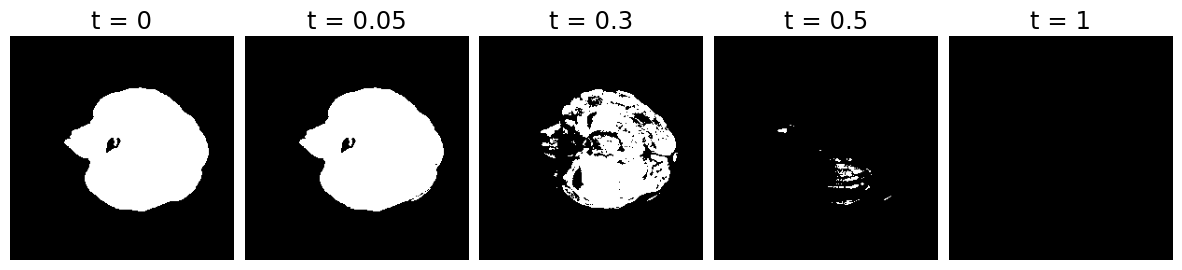

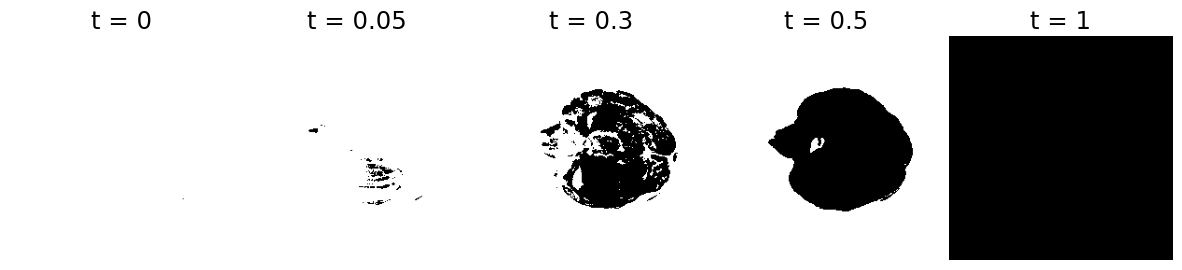

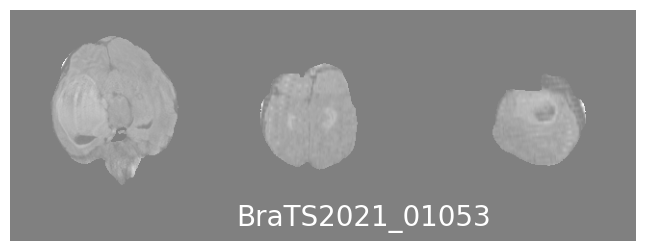

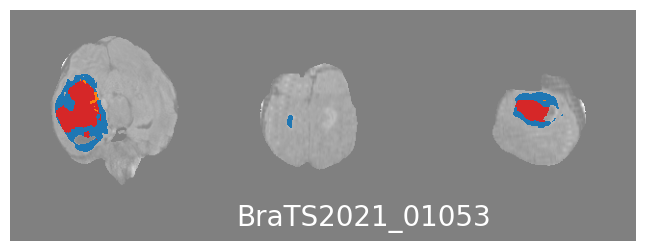

In [6]:
i = 0
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)

PlotSublevelSets(img_flair)
PlotSuperlevelSets(img_flair)

PlotSegmentation(pb,img_flair,None,figsize=(9,3))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(9,3))

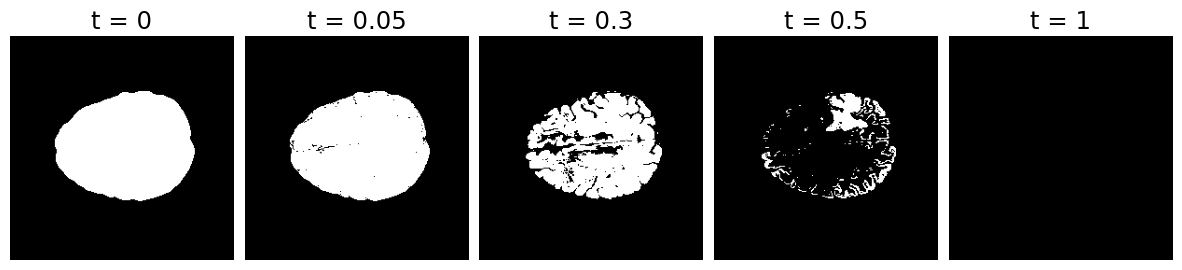

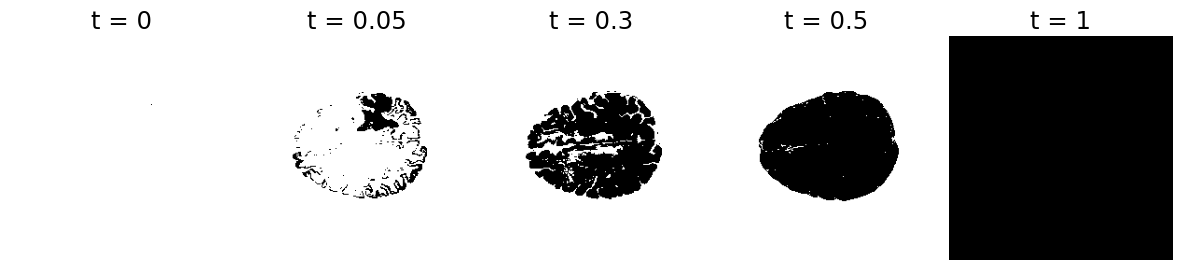

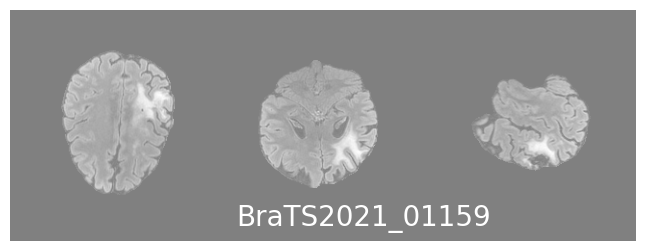

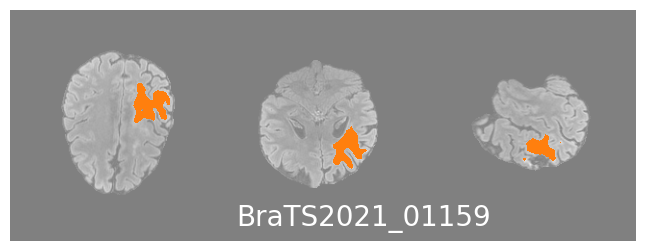

In [7]:
i = 1
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)

PlotSublevelSets(img_flair)
PlotSuperlevelSets(img_flair)

PlotSegmentation(pb,img_flair,None,figsize=(9,3))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(9,3))

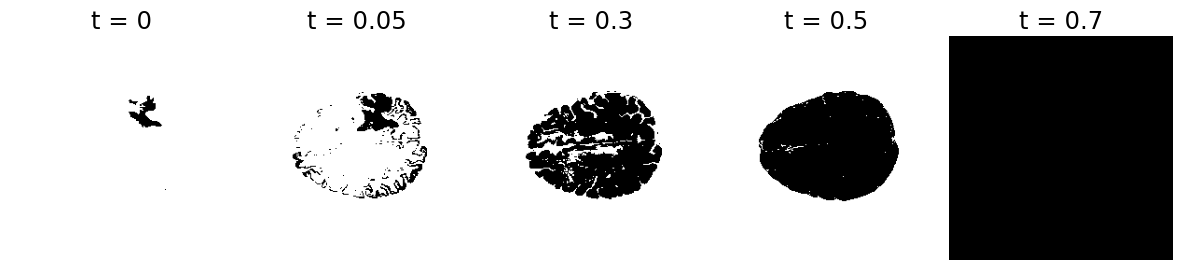

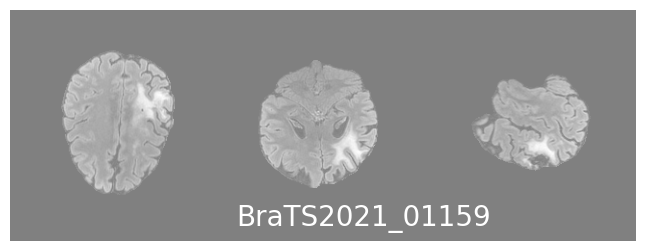

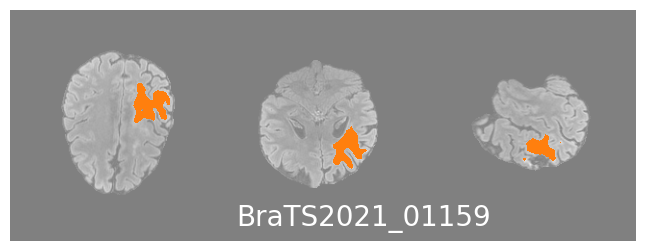

In [15]:
i = 1
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)

PlotSuperlevelSets(img_flair,Times=[0,0.05,0.3,0.5,0.7])

PlotSegmentation(pb,img_flair,None,figsize=(9,3))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(9,3))

In [68]:
def PlotSuperlevelSets(image, pos=None, Times=[0,0.05,0.3,0.5,1]):
    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
#     ax.reverse()
    for i in range(len(Times)):
        t = Times[i]
#         imt = np.zeros(np.shape(im)); imt[im<t] = 1; imt[im>=t] = 0
        imt = np.zeros(np.shape(im)); imt[im>=t] = 1; imt[im<t] = 0
        ax[i].imshow(1-imt,origin='lower',vmin=0,vmax=1,cmap='gray')
#         ax[i].set_title('t = '+repr(round(1-Times[::-1][i],1)), fontsize=17.5); 
        ax[i].set_title('t = '+repr(round(Times[i],1)), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)

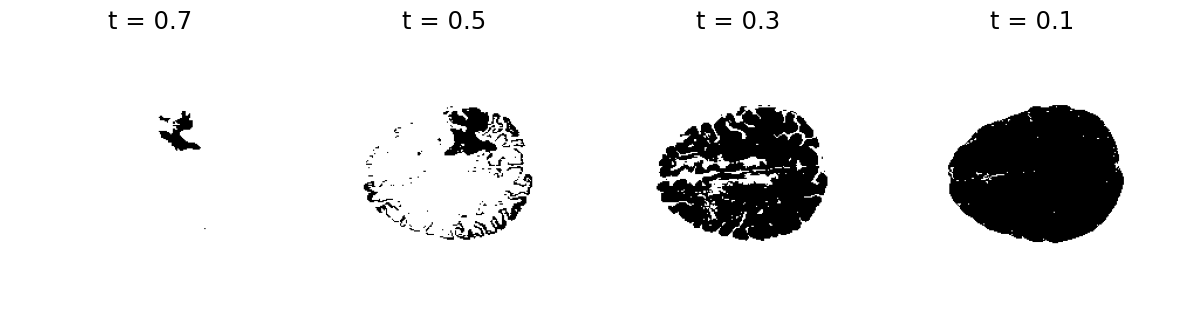

In [74]:
i = 1
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)

PlotSuperlevelSets(img_flair,Times=[0.05,0.3,0.5,0.7][::-1])

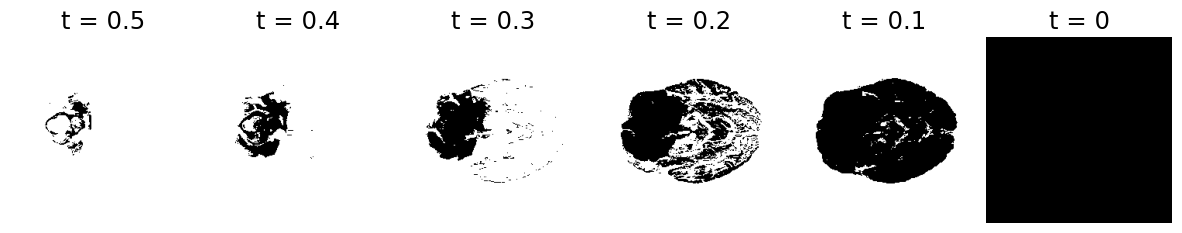

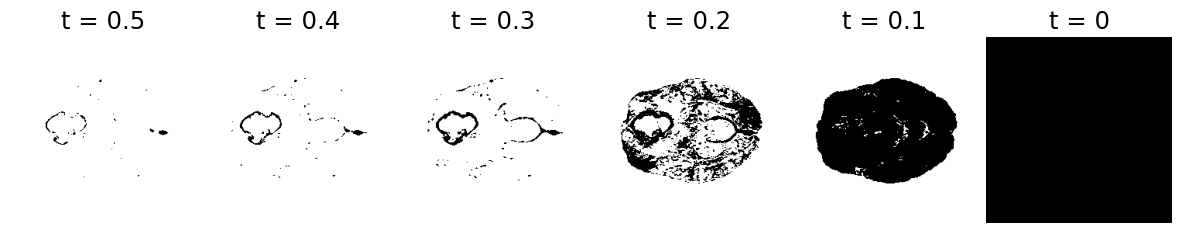

In [61]:
i = 557
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)

pos = argmax_image(img_flair)
Times=[0.5,0.4,0.3,0.2,0.1,0]
PlotSuperlevelSets(img_flair,pos=pos,Times=Times)
PlotSuperlevelSets(img_t1ce,pos=pos,Times=Times)


# PlotSegmentation(pb,img_flair,None,figsize=(9,3))
# PlotSegmentation(pb,img_flair,seg_medecin,figsize=(9,3))

/home/raph/GoogleDrive/2 - Professionnel/TDA+Segmentations/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


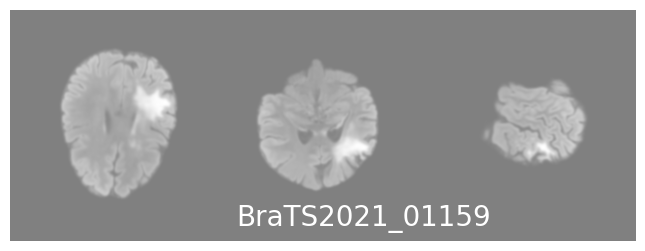

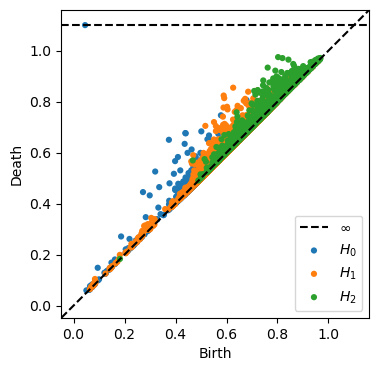

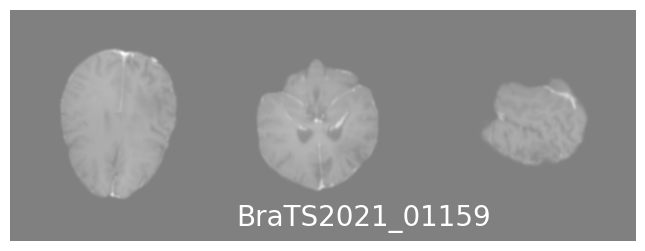

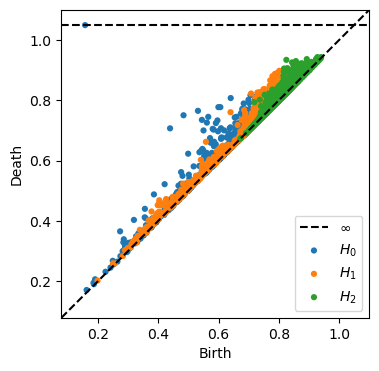

In [66]:
# Plot persistence diagrams

i = 1
sigma = 1

pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

img = img_flair
PlotSegmentation(pb,img,None,figsize=(9,3))
barcode = cripser.computePH(1-img,maxdim=2) # Compute diagram -> 2 is enough?!
H0 = np.array([bar[1:3] for bar in barcode if bar[0]==0])
H1 = np.array([bar[1:3] for bar in barcode if bar[0]==1])
H2 = np.array([bar[1:3] for bar in barcode if bar[0]==2])
plt.figure(figsize=(4,4))
persim.plot_diagrams([H0,H1,H2])

img = img_t1ce
PlotSegmentation(pb,img,None,figsize=(9,3))
barcode = cripser.computePH(1-img,maxdim=2) # Compute diagram -> 2 is enough?!
H0 = np.array([bar[1:3] for bar in barcode if bar[0]==0])
H1 = np.array([bar[1:3] for bar in barcode if bar[0]==1])
H2 = np.array([bar[1:3] for bar in barcode if bar[0]==2])
plt.figure(figsize=(4,4))
persim.plot_diagrams([H0,H1,H2])

/home/raph/GoogleDrive/2 - Professionnel/TDA+Segmentations/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


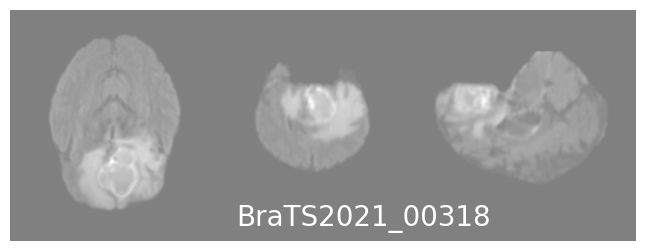

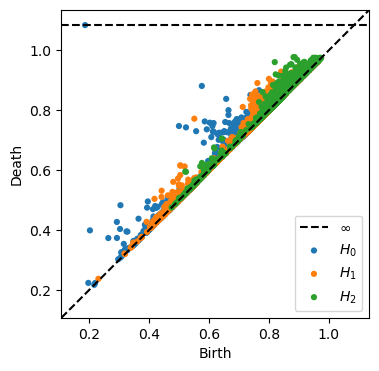

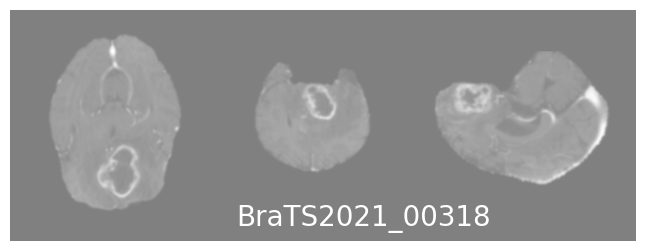

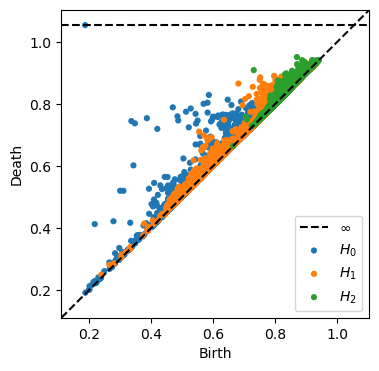

In [67]:
# Plot persistence diagrams

i = 557
sigma = 1

pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

img = img_flair
PlotSegmentation(pb,img,None,figsize=(9,3))
barcode = cripser.computePH(1-img,maxdim=2) # Compute diagram -> 2 is enough?!
H0 = np.array([bar[1:3] for bar in barcode if bar[0]==0])
H1 = np.array([bar[1:3] for bar in barcode if bar[0]==1])
H2 = np.array([bar[1:3] for bar in barcode if bar[0]==2])
plt.figure(figsize=(4,4))
persim.plot_diagrams([H0,H1,H2])

img = img_t1ce
PlotSegmentation(pb,img,None,figsize=(9,3))
barcode = cripser.computePH(1-img,maxdim=2) # Compute diagram -> 2 is enough?!
H0 = np.array([bar[1:3] for bar in barcode if bar[0]==0])
H1 = np.array([bar[1:3] for bar in barcode if bar[0]==1])
H2 = np.array([bar[1:3] for bar in barcode if bar[0]==2])
plt.figure(figsize=(4,4))
persim.plot_diagrams([H0,H1,H2])

# Pre-processing

# Step 1

In [45]:
def Step1_tuneparameter(img_flair,seg_medecin=None,method='suggest_t',dt_threshold=1,verbose=True,plot=True):
    '''
    method can be 'suggest_t', 'medecin' or 'medecin_hull'
    '''        
    # Build suggestion curve
    N = 100
    T = np.linspace(0,1,N)
    if verbose: start_time = ChronometerStart('Suggest t... ')
    S = np.array([np.sum(img>t) for t in T])
    S_dt = (S[:-1] - S[1:])                #finite differences
    S_dt_norm = S_dt*len(S_dt)/S_dt.sum()  #S_dt_norm has integral 1, i.e., np.sum(S_dt_norm)/len(S_dt) = 1
    if verbose: ChronometerStop(start_time, method='s')
            
    Scores = []
    for t in T:
        # Extract CC
        seg_union = get_largest_CC(img_flair, t, verbose=verbose)

        # Fill CC with holes
        seg_union = scipy.ndimage.binary_fill_holes(seg_union)
        
        # Compute score
        Scores.append( DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=False) )
        
    # Find optimal parameter
    dt_threshold_optimal = S_dt_norm[np.argmax(Scores)]
    
    return dt_threshold_optimal, np.max(Scores)

def BoxplotSegUnion(dic,titles):
    plt.figure(figsize =(len(dic)*3, 2))
    indices = sorted(dic.keys())
    for i in range(len(dic)):
        index = indices[i]
        scores = dic[index]
        ax = plt.subplot(1,len(dic),i+1)
        ax.boxplot(scores, showmeans=True, notch = True)
        title = titles[index]+', mn='+repr(round(np.mean(scores),2))+', md='+repr(round(np.median(scores),2))
        ax.title.set_text(title); ax.title.set_size(12)
        ax.set_ylim(-0.01,1)

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


Suggest t... Execution time: 1 s.


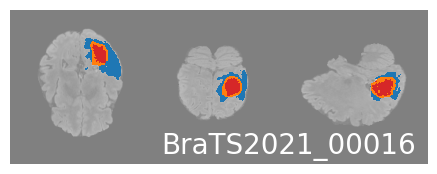

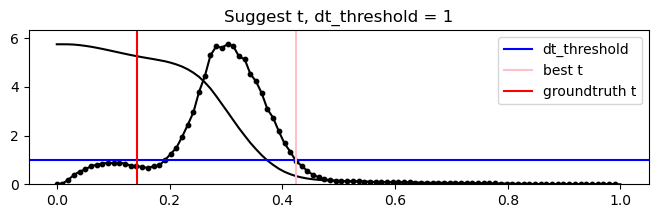

Get largest connected component... Execution time: 20 s.
Fill the holes... Execution time: 0 s.
Sørensen–Dice coefficient:  0.828 0.862 0.796


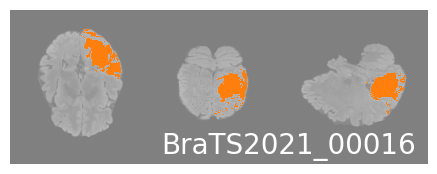

In [15]:
# Step 1 without smoothing

i = 2
sigma = 0
dt_threshold = 1

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

# Step 1
dt_threshold = 1
seg_union = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=True,plot=True)
PlotSegmentation(pb,img_flair,seg_union,figsize=(6,2))
DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True);

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


Suggest t... Execution time: 1 s.


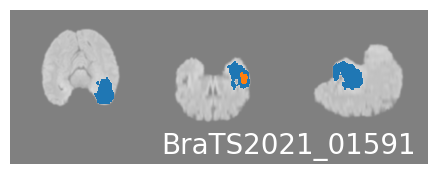

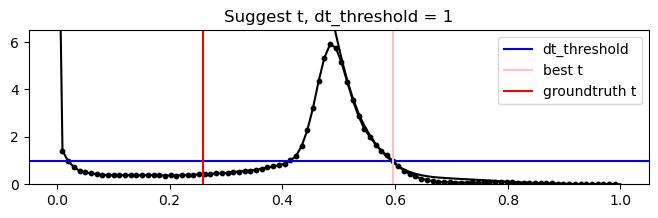

Get largest connected component... Execution time: 1 s.
Fill the holes... Execution time: 0 s.
Sørensen–Dice coefficient:  0.859 0.788 0.944


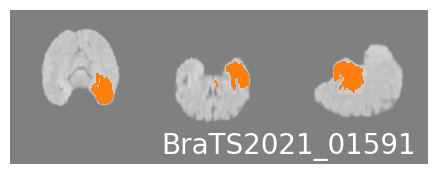

In [16]:
# Step 1 with smoothing

i = 5
sigma = 1
dt_threshold = 1

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

# Step 1
dt_threshold = 1
seg_union = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=True,plot=True)
PlotSegmentation(pb,img_flair,seg_union,figsize=(6,2))
DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True);

Tune parameter for sigma=1... 0 dt_opt 0.8832933458567945 best_score 0.8220329907591329
Tune parameter for sigma=1... It 1/20. Duration 0:01:35 Expected remaining time 0:30:13.1 dt_opt 0.0796569999172673 best_score 0.837669051656396
Tune parameter for sigma=1... It 2/20. Duration 0:03:17 Expected remaining time 0:29:29.2 dt_opt 0.4994087044544264 best_score 0.8969012980102776
Tune parameter for sigma=1... It 3/20. Duration 0:04:46 Expected remaining time 0:27:03.3 dt_opt 2.950681571532161 best_score 0.9433170693681149
Tune parameter for sigma=1... It 4/20. Duration 0:06:17 Expected remaining time 0:25:07.4 dt_opt 0.6645042607345691 best_score 0.8919405323245918
Tune parameter for sigma=1... It 5/20. Duration 0:07:44 Expected remaining time 0:23:11.5 dt_opt 0.06782622237579143 best_score 0.8592255966043437
Tune parameter for sigma=1... It 6/20. Duration 0:09:11 Expected remaining time 0:21:26.6 dt_opt 0.2926645285938846 best_score 0.8391144896693079
Tune parameter for sigma=1... It 7/20

KeyboardInterrupt: 

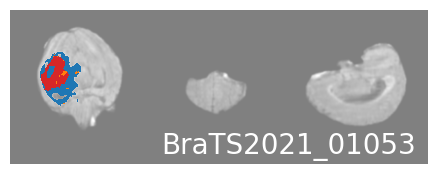

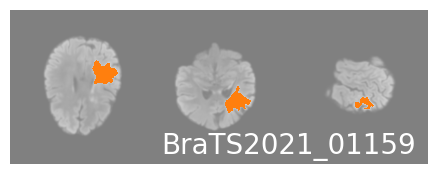

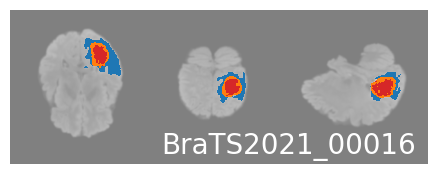

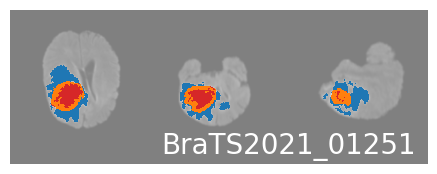

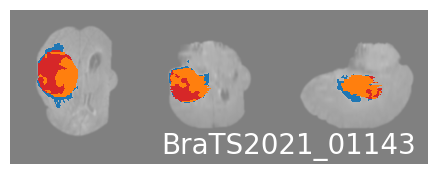

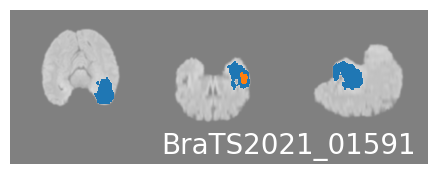

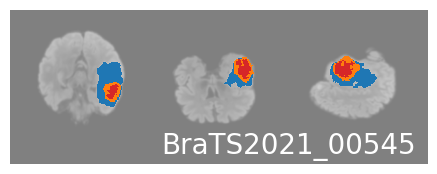

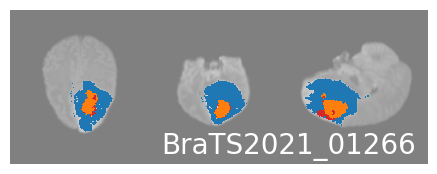

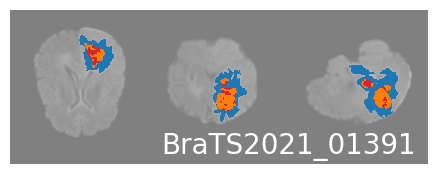

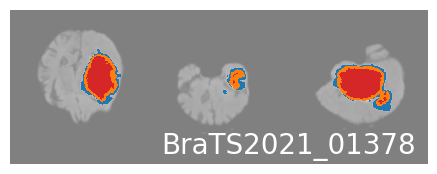

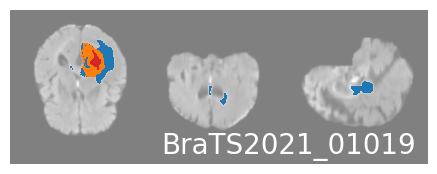

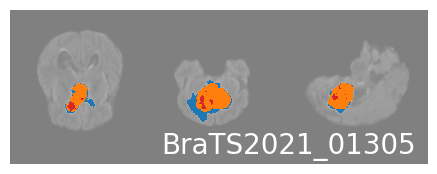

In [82]:
# # Tune parameter dt_threshold

# N_max = 20
# sigma = 1

# msg = 'Tune parameter for sigma='+repr(sigma)+'... '
# start_time = ChronometerStart(msg)
# for i in range(N_max):
#     # Open image
#     pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
#     img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
#     PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

#     dt_opt, best_score = Step1_tuneparameter(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=True)
#     print(i, 'dt_opt', dt_opt, 'best_score', best_score)
    
#     ChronometerTick(start_time, i, 20, msg)

In [85]:
# optimal_dt_threshold = np.array([0.8832933458567945,0.0796569999172673,0.4994087044544264,0.4994087044544264,
#                                0.6645042607345691,0.06782622237579143,0.2926645285938846,1.2775098427591844,
#                                2.8977910366408572,2.356037784515357,0.8832933458567945])

In [88]:
# for i in range(len(optimal_dt_threshold)):
#     # Open image
#     pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
#     img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
#     dt_threshold = optimal_dt_threshold[i]
#     seg_union = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)
#     print('\n', i)
#     DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True);
#     seg_union = scipy.ndimage.morphology.binary_closing(seg_union, iterations=1)
#     DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True);


 0
Sørensen–Dice coefficient:  0.79 0.962 0.67
Sørensen–Dice coefficient:  0.796 0.961 0.679

 1
Sørensen–Dice coefficient:  0.822 0.966 0.715
Sørensen–Dice coefficient:  0.823 0.965 0.716

 2
Sørensen–Dice coefficient:  0.897 0.938 0.859
Sørensen–Dice coefficient:  0.9 0.936 0.866

 3
Sørensen–Dice coefficient:  0.909 0.852 0.975
Sørensen–Dice coefficient:  0.907 0.849 0.975

 4
Sørensen–Dice coefficient:  0.863 0.992 0.763
Sørensen–Dice coefficient:  0.865 0.992 0.767

 5
Sørensen–Dice coefficient:  0.295 1.0 0.173
Sørensen–Dice coefficient:  0.296 1.0 0.174

 6
Sørensen–Dice coefficient:  0.822 0.996 0.7
Sørensen–Dice coefficient:  0.826 0.996 0.705

 7
Sørensen–Dice coefficient:  0.783 0.653 0.979
Sørensen–Dice coefficient:  0.78 0.649 0.979

 8
Sørensen–Dice coefficient:  0.766 0.621 0.999
Sørensen–Dice coefficient:  0.761 0.615 0.999

 9
Sørensen–Dice coefficient:  0.829 0.709 0.998
Sørensen–Dice coefficient:  0.826 0.705 0.998

 10
Sørensen–Dice coefficient:  0.641 0.918 0.492


Compute DICEs for sigma=0.1... It 2/2. Duration 0:00:31 Expected remaining time 0:00:00.
Compute DICEs for sigma=0.5... It 2/2. Duration 0:00:20 Expected remaining time 0:00:00.
Compute DICEs for sigma=1... It 2/2. Duration 0:00:08 Expected remaining time 0:00:00.
Compute DICEs for sigma=2... It 2/2. Duration 0:00:06 Expected remaining time 0:00:00.
Compute DICEs for sigma=3... It 2/2. Duration 0:00:06 Expected remaining time 0:00:00.


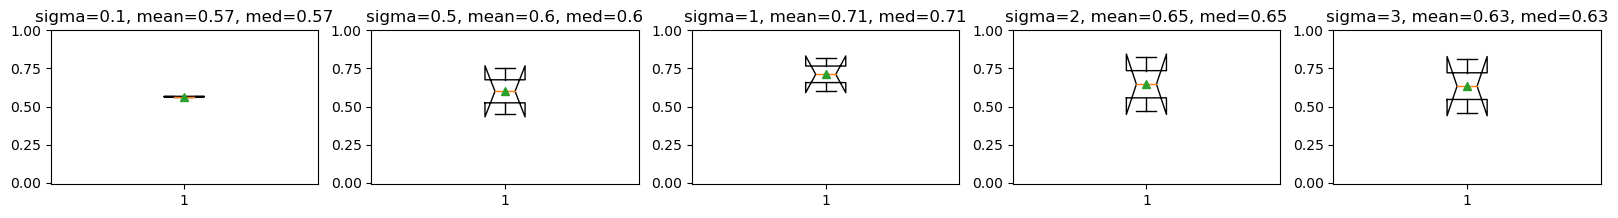

In [26]:
# Batch Step 1 - new (image in [0,1])

i_list = range(2)

dt_threshold = 1
#sigmas = [0.1, 0.5, 1][::-1]
sigmas = [0.1, 0.5, 1, 2, 3]
DICEs = {sigma:[None for i in i_list] for sigma in sigmas}

for sigma in sigmas:
    msg = 'Compute DICEs for sigma='+repr(sigma)+'... '
    start_time = ChronometerStart(msg)
    for i in i_list:
        # Open image
        pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
        img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
        # Step 1
        seg_union = Step1(img_flair,verbose=False,plot=False)
        DICEs[sigma][i] = DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=False)
        ChronometerTick(start_time, i, len(i_list), msg)
        
# Batch Step 1 - Boxplots

titles = {sigma:'sigma='+repr(sigma) for sigma in sigmas}
BoxplotSegUnion(DICEs,titles)

In [19]:
# sigmas = [0.1, 0.5, 1][::-1]
# DICEs = {1: [0.819708433290275, 0.6026785117000923, 0.859769585532735, 0.8582138319114176, 0.8919405323245918, 0.8592255966043437, 0.7427459900193275, 0.8368093363486613, 0.9114987629575115, 0.9399666998937464, 0.6781920868938696, 0.9444824326770308, 0.8778245563509176, 0.00013952074623667702, 0.9248127222862902, 0.5623454013941983, 0.7663121667748033, 0.8498008218530302, 0.7378098142500693, 0.8496660450475473, 0.8184797649972081, 0.8608227068961513, 0.2596164570113701, 0.9524424901845899, 0.2557219502501942, 0.9324063700951544, 0.8160871284223055, 0.5321247242085116, 0.9224364391512555, 0.8893954466895496, 0.8242283987059296, 0.0, 0.5298328323349408, 0.23691886964448497, 0.7577114264081377, 0.658040915865059, 0.6098604412683661, 0.7315122508551564, 0.8418275901942646, 0.839977418794511, 0.9408013540257611, 0.8325428707183276, 0.0, 0.8047940621767963, 0.9186337230678726, 0.9275848768042877, 0.9440396675540957, 0.6508288199573281, 0.9502587898364185, 0.7943798091050576, 0.9275065702258297, 0.8729103366100686, 0.5829907925024663, 0.6446010878314106, 0.7930533060635795, 0.6252406211233263, 0.9361579380498689, 0.9518327779460769, 0.9048962860732898, 0.6700143824755068, 0.3235714507659323, 0.0, 0.8862479087175139, 0.7370629737456396, 0.0, 0.8830702898357863, 0.48274154273686526, 0.8298407097321859, 0.8111584895295149, 0.879213417256343, 0.8775710542385197, 0.6133532635774788, 0.7669112838770616, 0.9439511294839843, 0.8466953134143691, 0.9299596571604809, 0.7572048801226472, 0.9199162450221884, 0.0, 0.892106469750718, 0.8069244066149686, 0.30031758944914655, 0.8508346647567627, 0.5635427064023956, 0.8276094177556007, 0.7541280089703941, 0.13329319988963304, 0.1748261602083014, 0.6384275466918861, 0.84474337717291, 0.9282827139365931, 0.8501449717686556, 0.6994126934006947, 0.8900010671803726, 0.8526466459913341, 0.9052825365380238, 0.8410011217817177, 0.7473803376143924, 0.8869406636420247, 0.0], 0.5: [0.7497112222843827, 0.44834275636703147, 0.857764769705778, 0.8724668258286603, 0.8790645135629623, 0.8535638673253352, 0.7298311444652908, 0.8169553137046026, 0.9119506682876819, 0.9509907674342225, 0.6018274915839203, 0.941132687239043, 0.8524726590407701, 0.00013151172730537528, 0.9080429815883554, 0.4525564228232589, 0.6429586436691493, 0.8226400864926013, 0.734672139665385, 0.806970914779898, 0.8474916337124023, 0.846259687415474, 0.22902440189102719, 0.9402898933100275, 0.20648055276941937, 0.9524295842398947, 0.8226358972645088, 0.5391479409065341, 0.9208928577571232, 0.8561653259463773, 0.6110884117352803, 0.0, 0.5088659884423546, 0.2509098329988776, 0.637707265935299, 0.6012576037181327, 0.5557453111067451, 0.6976227629932661, 0.8050392721051404, 0.8290222222222222, 0.9144715909475551, 0.868524499400203, 0.0, 0.6993790138527679, 0.8874217954313982, 0.9302778169510647, 0.9622615855681429, 0.5504215083162451, 0.9269644472354571, 0.7234216675460605, 0.9459095738401605, 0.8622281450533354, 0.5892250145780887, 0.7218743929590724, 0.7131925622439332, 0.6574458709127765, 0.9320206565397277, 0.9505546919715883, 0.8907190414633808, 0.5914881127091283, 0.325422703433673, 0.7275489010818686, 0.8185681691326955, 0.6896316149035683, 0.0, 0.9181184668989547, 0.540835289838299, 0.8152499659446942, 0.819976548059915, 0.8915271281944865, 0.8465338621156876, 0.637202510408252, 0.7107120338506651, 0.9023158060919415, 0.7994584916371894, 0.9424758328854437, 0.7229398747943184, 0.9140584269136367, 0.0, 0.8945692315296676, 0.7751014979547535, 0.27857895481780864, 0.7526258135189123, 0.5857742249796178, 0.7892942027487858, 0.7114987807165635, 0.12628066425089288, 0.11126946770306889, 0.8476432591455615, 0.7952429374940417, 0.9305589840642914, 0.7950870533270066, 0.6374452706928904, 0.873740032893487, 0.8698614033644069, 0.8882190266999652, 0.8444162883187274, 0.640709910087936, 0.9220242025229042, 0.0], 0.1: [0.5620730894497256, 0.5658438203644099, 0.8262511605827696, 0.9100405626771367, 0.8592197958745584, 0.84583578028932, 0.7398363479758828, 0.8216968464343302, 0.8885890801357693, 0.7451356056158133, 0.5598726297134577, 0.9217460840623092, 0.8035707553295325, 0.00010176097364899587, 0.8968794526526578, 0.4269951781145444, 0.5568538620256571, 0.8133298484056456, 0.6743825481449244, 0.7666010859189643, 0.8479660554505838, 0.8262863574858402, 0.0, 0.9324489750495226, 0.0, 0.9465023045449602, 0.8449329758713137, 0.5330697032941549, 0.9077846744476048, 0.8108408857083245, 0.7341235609231391, 0.0, 0.4801104534703439, 0.29146127496031415, 0.605370294131101, 0.5871001165652118, 0.605411657495356, 0.6660190286913511, 0.7725588928622974, 0.803135767638693, 0.8954232850650401, 0.8672094092047383, 0.0, 0.6623000927896949, 0.8669318003561772, 0.9156195176220564, 0.9545939641988755, 0.49730016391861925, 0.9028203157334594, 0.6661955875590251, 0.9494784406095275, 0.8447035842187823, 0.8052972896411481, 0.7049162378188985, 0.6709714374983727, 0.6829137688967251, 0.929199879357146, 0.9319020698779549, 0.8730084942737607, 0.43734928416768654, 0.32534446764091857, 0.6862592406899716, 0.7665889379806906, 0.5994704299939437, 0.0, 0.9211198799564504, 0.4348473936474036, 0.810173488293751, 0.8488123187405054, 0.8916484583636805, 0.8483812540674471, 0.6214581446500194, 0.6554592556208705, 0.9056035059203555, 0.7690527345064073, 0.9529483975848847, 0.7649675931011755, 0.7249106489884081, 0.0, 0.8902841579664095, 0.7464045955369915, 0.2766744852749544, 0.7447152717860225, 0.5657721343126538, 0.7463040834566527, 0.6758373205741627, 0.12020896636281252, 0.09305219564156936, 0.801974776110601, 0.7441030260567845, 0.8843911411564279, 0.8271020665720145, 0.520721636194044, 0.9166859299790786, 0.8496867518505948, 0.8600053738544828, 0.8464334917806935, 0.5570889181307818, 0.9271751091505862, 0.0]}

In [23]:
# DICEs = {1: [0.8197054079888983, 0.6026785117000923, 0.8599059576324591, 0.8580918184925602, 0.8919405323245918, 0.8592255966043437, 0.7427538033210699, 0.8368070000083759, 0.9114987629575115, 0.9399641258061424, 0.679256237372369, 0.9445363281269638, 0.8778245563509176, 0.00013952074623667702, 0.9248127222862902, 0.5624019742870474, 0.7663013582702154, 0.8498008218530302, 0.7378098142500693, 0.8496660450475473, 0.8184539343518085, 0.8608227068961513, 0.2596164570113701, 0.9524424901845899, 0.2557219502501942, 0.9324139398021768, 0.8160964515419041, 0.5321020930022381, 0.9224757706076755, 0.8893954466895496, 0.8242450575711493, 0.0, 0.5298328323349408, 0.2369116708699219, 0.7577114264081377, 0.658040915865059, 0.6098604412683661, 0.7315122508551564, 0.8418275901942646, 0.839977418794511, 0.9407825472766769, 0.8325428707183276, 0.0, 0.8049540123606989, 0.9186337230678726, 0.9275848768042877, 0.9440396675540957, 0.6508288199573281, 0.9502587898364185, 0.7943798091050576, 0.9275065702258297, 0.8729103366100686, 0.5829907925024663, 0.6446010878314106, 0.7930533060635795, 0.625237277894523, 0.9361579380498689, 0.951779069318516, 0.9048962860732898, 0.6700143824755068, 0.3235952088738368, 0.0, 0.8862479087175139, 0.7370629737456396, 0.0, 0.8830702898357863, 0.48276763389863153, 0.8298407097321859, 0.8111584895295149, 0.879213417256343, 0.8775710542385197, 0.6133447746114348, 0.7669112838770616, 0.9439511294839843, 0.8466953134143691, 0.9299596571604809, 0.7572048801226472, 0.9199182446292498, 0.0, 0.892106469750718, 0.8069317252998381, 0.30029879699012874, 0.8508346647567627, 0.5633870579745008, 0.8276094177556007, 0.7541280089703941, 0.1332798274435053, 0.1748250891402105, 0.6383639973234677, 0.8447563779864281, 0.9282613327651414, 0.8501449717686556, 0.6994373330470531, 0.8897770701508175, 0.8526442807805934, 0.9052825365380238, 0.8410050856210648, 0.7473803376143924, 0.8869604668540725, 0.0], 0.5: [0.7507670777855078, 0.44854290423910675, 0.8583438757137024, 0.8724399151162217, 0.8792784767843225, 0.853685213280175, 0.7298314666103127, 0.816926696554318, 0.9119719517539681, 0.9509800894333362, 0.6018896441358798, 0.9411434834697051, 0.8525627438512203, 0.00013151106210357002, 0.9081092841981162, 0.45308993691290594, 0.6429586436691493, 0.8226445998574181, 0.7351035512562488, 0.8068901357676541, 0.8472627441445822, 0.8463275241656671, 0.22902440189102719, 0.940296374469582, 0.20653884908455183, 0.9527187985499741, 0.8233909439600663, 0.5391706979140145, 0.9211871954553427, 0.8561255324905195, 0.6112390093422977, 0.0, 0.5089478945807288, 0.2508757014113246, 0.6377380776613022, 0.6013054027269932, 0.5557335428882306, 0.6977326079928028, 0.8118582209575652, 0.8296724042198779, 0.9147835501497132, 0.8684964497778516, 0.0, 0.6997585758628924, 0.8874217954313982, 0.9304738942233126, 0.9622728731243848, 0.550619646437033, 0.927038626609442, 0.7235041400622355, 0.9459095738401605, 0.8622281450533354, 0.5891998748471143, 0.721866969461543, 0.7131925622439332, 0.6573057792028564, 0.9320206565397277, 0.9522694344524381, 0.890834671058575, 0.5915393746494306, 0.3253642967006588, 0.727601492028394, 0.8188920106902662, 0.6896832591074502, 0.0, 0.9180729328999511, 0.5410861529712824, 0.8152499659446942, 0.8197170785981086, 0.891458116405156, 0.8467621026355244, 0.6372786579683132, 0.7107512097294916, 0.9025190271139456, 0.799607021220854, 0.9424669009944211, 0.7229342529141424, 0.9145596240209692, 0.0, 0.8948438470661321, 0.7754047935591052, 0.27849653372738276, 0.7526579635810663, 0.5857382867254526, 0.7892359470949457, 0.7114987807165635, 0.12625433315088488, 0.11132723702033719, 0.8478643135750368, 0.7957260783075842, 0.9306195491196314, 0.7950580334330973, 0.6376914311125934, 0.8754595725196631, 0.8704570686748474, 0.88852974554603, 0.8445662768888623, 0.6410959242384956, 0.9219543828056114, 0.0], 0.1: [0.5642245570313311, 0.5661954347976002, 0.8276775691486024, 0.9099677620632279, 0.8593134624453226, 0.8459335418389234, 0.7400551059066643, 0.8255739760222985, 0.889248068009185, 0.9511866157775418, 0.5599463069669984, 0.9232877599248956, 0.804031673848138, 0.00010175579626454471, 0.8970707516658624, 0.4275851044862376, 0.5569546448393788, 0.8133574174962538, 0.676173790218528, 0.767167740688826, 0.8478286916066535, 0.8266682626129631, 0.0, 0.9325083738579838, 0.0, 0.9467555885451227, 0.8451383339211651, 0.5330811008726429, 0.9081270352603382, 0.8111830101870788, 0.7347299397500585, 0.0, 0.4802082154577345, 0.291303077115778, 0.6055580115550542, 0.5871078447243177, 0.6054139290407359, 0.6663948402401957, 0.7725822228636487, 0.8042780254556374, 0.8955019538774837, 0.8672037665772542, 0.0, 0.6627927596131549, 0.8670258899079183, 0.9159674050204253, 0.9546577188591545, 0.49831374060512623, 0.9028981565784961, 0.6664199524514421, 0.9494784406095275, 0.8446985840791779, 0.8053243245976919, 0.7087829829704947, 0.6709714374983727, 0.6826706676669168, 0.9292275610092375, 0.9321652672877608, 0.873079929852733, 0.43786965114343007, 0.32506895164060734, 0.6869875792952717, 0.7672445516621008, 0.5995394658085051, 0.0, 0.9211439208054827, 0.43522489066706394, 0.8101862768215043, 0.8483046667793325, 0.891697072172288, 0.8492824465751708, 0.6214800685396528, 0.6555764157893486, 0.9062328115763231, 0.769545978274027, 0.9528311576266139, 0.764944560777179, 0.7253411315512074, 0.0, 0.891132002220537, 0.7468374377936176, 0.27889870057771377, 0.7447491169888646, 0.5660369655960727, 0.7462712808040555, 0.6759650442733954, 0.12017053024247269, 0.093011453534077, 0.8176859888922146, 0.7456775725263969, 0.8849884683218017, 0.8273795441999843, 0.5213271579202705, 0.9170648683741088, 0.8681201008259789, 0.8604255781193298, 0.8468703588885845, 0.557234193074904, 0.9273031364182778, 0.0]}

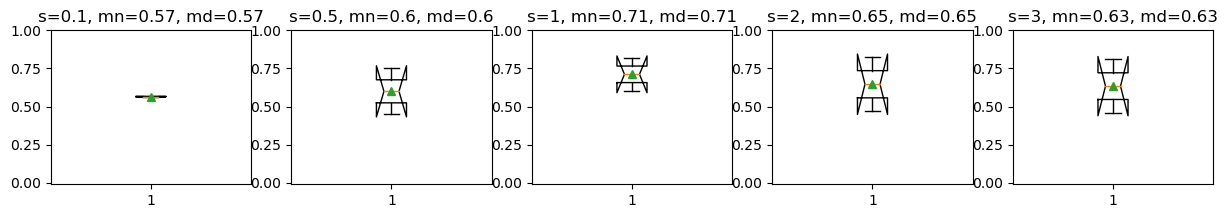

In [46]:
# Batch Step 1 - Boxplots

titles = {sigma:'s='+repr(sigma) for sigma in sigmas}
BoxplotSegUnion(DICEs,titles)

# Step 1 variation

With only selected pixel

In [47]:
def Step1_variation(img_flair,seg_medecin=None,method='suggest_t',dt_threshold=1,dt_threshold2=1,verbose=True,plot=True):
    '''
    method can be 'suggest_t', 'medecin' or 'medecin_hull'
    '''        
    if method=='suggest_t':
        # Find best t
        t = suggest_t(img_flair, dt_threshold=dt_threshold, verbose=verbose, plot=plot)
        print('t =',t)

        # Extract CC
        seg_union = get_largest_CC(img_flair, t, verbose=verbose)
        
        # VARIATION - lauch suggest_t again
        pos = argmax_image(img_flair*seg_union)
        t = suggest_t_variation(img_flair,seg_union, dt_threshold=dt_threshold2,pos=pos,verbose=verbose, plot=plot)
        print('t =',t)
        seg_union = GetConnectedComponent(img_flair, pos, t)

        # Fill CC with holes
        if verbose: start_time = ChronometerStart('Fill the holes... ')
        seg_remaining = (seg_union>0)*1-1
        seg_remaining[seg_remaining<0]=1
        labels = skimage.measure.label(seg_remaining, background=0) #scipy.ndimage.label(seg_union_nocontour)
        components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
        if len(components)>0:
            components_cardinal = [np.sum(component) for component in components]
            cardinalmax = max(components_cardinal)
            remainingcomponents = np.sum([components[i] for i in range(len(components)) if components_cardinal[i]<cardinalmax],0)
            seg_union[remainingcomponents>0] = 1
        if verbose: ChronometerStop(start_time, method='s')

    elif method=='medecin': seg_union = (seg_medecin>0)*1

    elif method=='medecin_hull': 
        # Take convex hull of seg_union
        seg_union = (seg_medecin>0)*1
        if verbose: start_time = ChronometerStart('Take convex hull... ')
        seg_union = (seg_medecin>0)*1
        seg_union = skimage.morphology.convex_hull_image(seg_union)
        seg_union = seg_union*1
        if verbose: ChronometerStop(start_time, method='s')

    return seg_union

def suggest_t_variation(img, seg_union, N=100, dt_threshold=1, pos=None, verbose=False, plot=False):
    if verbose: start_time = ChronometerStart('Suggest t... ')
    # Find best t
    T = np.linspace(0,1,N)
    S = np.array([np.sum(GetConnectedComponent(img, pos, t)) for t in T])
    S_dt = (S[:-1] - S[1:])*N
    S_dt_norm = S_dt*len(S_dt)/S_dt.sum()    
    best_i = np.where(S_dt_norm>dt_threshold)[0][-1]
    best_t = T[best_i+1]
    if verbose: ChronometerStop(start_time, method='s')

    if plot:
        fig, axs = plt.subplots(1, 1, figsize = (8,1))
        plt.plot(T,S/np.max(S)*np.max(S_dt_norm),c='black')
        plt.plot(T[0:-1],S_dt_norm, c='blue')
#        plt.scatter(T[0:-1],S_dt_norm,c='blue')
        plt.axhline(dt_threshold, c='pink')
        plt.axvline(best_t, c='pink')
        plt.axvline(np.min(img[seg_union>0]), c='red')
        plt.title('Suggest t variation, dt_threshold = '+repr(dt_threshold))
        plt.ylim(np.min(S_dt_norm[1::]),np.max(S_dt_norm[1::]))
        plt.show()

    return best_t

In [48]:
# Step 1

i = 2
sigma = 1
dt_threshold = 1

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
#PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

# Step 1
dt_threshold = 1
seg_union = Step1(img_flair,verbose=True,plot=False)
#PlotSegmentation(pb,img_flair,seg_union,figsize=(6,2))
DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True);

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


Suggest t... Execution time: 1 s.
Get largest connected component... Execution time: 2 s.
Fill the holes... Execution time: 0 s.
Sørensen–Dice coefficient:  0.86 0.784 0.952


Suggest t... Execution time: 1 s.


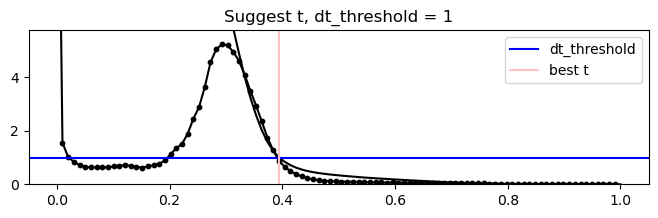

t = 0.393939393939394
Get largest connected component... Execution time: 2 s.
Suggest t... Execution time: 12 s.


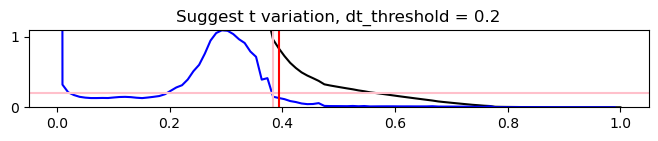

t = 0.38383838383838387
Fill the holes... Execution time: 3 s.
Sørensen–Dice coefficient:  0.812 0.696 0.973


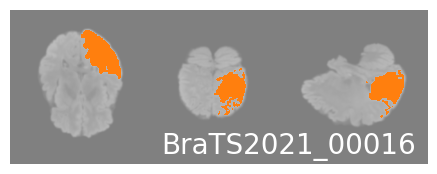

In [49]:
# Step 1 variation

i = 2
sigma = 1
dt_threshold = 1
dt_threshold2 = dt_threshold/5

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
#PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

# Step 1
dt_threshold = 1
seg_union = Step1_variation(img_flair,dt_threshold2=dt_threshold2,verbose=True,plot=True)
PlotSegmentation(pb,img_flair,seg_union,figsize=(6,2))
DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True);

# Step 2

In [183]:
# def Step2(img_t1ce,seg_union,verbose=True,plot=True):
#     # Compute PH2
#     if verbose: start_time = ChronometerStart('Compute diagram... ')
#     seg_union_t1ce = img_t1ce*seg_union
#     barcode = cripser.computePH(1-seg_union_t1ce,maxdim=3) # Compute diagram
#     H2 = [list(bar[1::]) for bar in barcode if bar[0]==2 and bar[2]<1] # Only non-infinite bars
#     H2 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H2],H2))[::-1]] # Sort list H2 by persistence
#     if verbose: ChronometerStop(start_time, method='s')

#     # Plot diagram
#     if plot and len(H2)>0:
#         fig, ax = plt.subplots(1,1, figsize=(4,4))
#         persim.plot_diagrams([np.array([barcode[0][1:3]]), np.array([barcode[0][1:3]]), np.array([bar[1:3] for bar in barcode if bar[0]==3-1])])
#         plt.title('Persistence diagram of t1ce segmented',fontsize=10)

#     # Extract contour H2
#     i = 0 # select the ith top bar
#     if len(H2)<=i:
#         seg_contour = 0*seg_union_t1ce
#     else:
#         bar = H2[i]
#         pos = np.array(bar[2:5]).astype(int)
#         t = bar[0]+0.0001
#         seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)

#     # Plot
#     if plot: patch = plt.Circle((bar[0],bar[1]), 0.01,fill=False); ax.add_patch(patch)
#     return seg_contour

Suggest t... Execution time: 1 s.
Get largest connected component... Execution time: 2 s.
Fill the holes... Execution time: 0 s.
Sørensen–Dice coefficient:  0.818 0.694 0.997
Compute diagram... Execution time: 19 s.
Width of the holes: {0: 242, 1: 1413, 2: 408, 3: 18755, 4: 20188}
Sørensen–Dice coefficient:  0.22 0.124 0.989


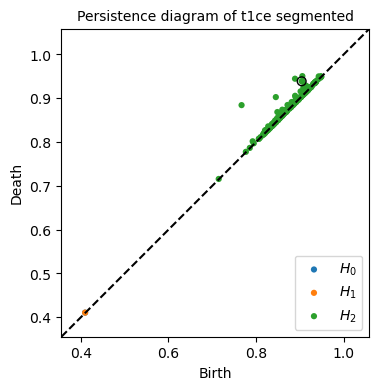

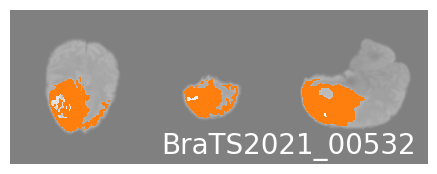

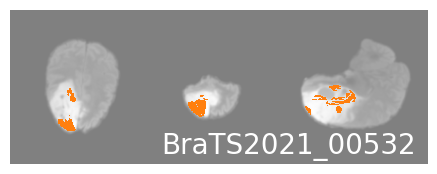

In [52]:
# Step 1 & 2

i = 20
sigma = 1
dt_threshold = 1

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
#PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

# Step 1
seg_union = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=True,plot=False)
#PlotSegmentation(pb,img_flair,seg_union,figsize=(6,2))
DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True)

# Step 2
seg_contour = Step2(img_t1ce,seg_union,verbose=True,plot=True)
DICE((seg_contour!=0)*1,(seg_medecin==4)*1, verbose=True);
PlotSegmentation(pb,img_flair,seg_contour,figsize=(6,2))
PlotSegmentation(pb,img_flair,(seg_medecin==4)*1,figsize=(6,2))

Sørensen–Dice coefficient:  0.218 0.123 0.99


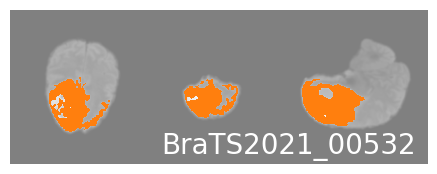

In [53]:
# Smooth via binary closing (test if this improves the Dice)
iterations = 1
if iterations>0: seg_contour2 = scipy.ndimage.morphology.binary_closing(seg_contour, iterations=iterations)
DICE((seg_contour2!=0)*1,(seg_medecin==4)*1, verbose=True);
PlotSegmentation(pb,img_flair,seg_contour2,figsize=(6,2))

Sørensen–Dice coefficient:  0.945 0.899 0.995
Sørensen–Dice coefficient:  0.937 0.921 0.955


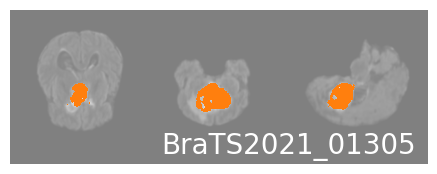

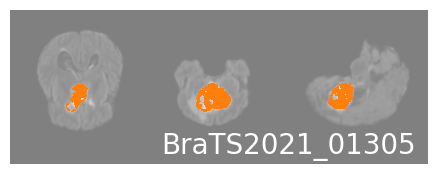

In [59]:
# Step 1 & 2

i = 11
sigma = 1
dt_threshold = 1

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)
#PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

# Step 1
seg_union = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)
#PlotSegmentation(pb,img_flair,seg_union,figsize=(6,2))
DICE((seg_union!=0)*1,(seg_medecin!=0)*1, verbose=True)

# Step 2
seg_contour = Step2(img_t1ce,seg_union,verbose=False,plot=False)
DICE((seg_contour!=0)*1,(seg_medecin==4)*1, verbose=True);
PlotSegmentation(pb,img_flair,seg_contour,figsize=(6,2))
PlotSegmentation(pb,img_flair,(seg_medecin==4)*1,figsize=(6,2))

# Step 3

Sørensen–Dice coefficients: {1: 0.914, 2: 0.785, 4: 0.906}


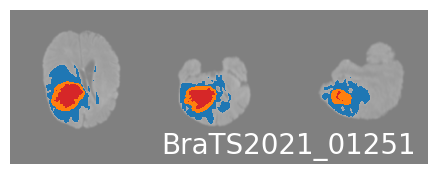

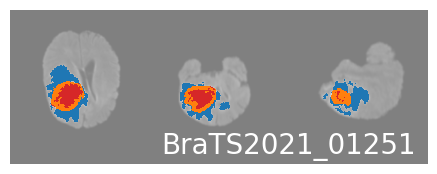

In [63]:
' Full segmentation '

i = 3

# Parameters
sigma = 1
dt_threshold = 1
H2_features_max = 5
alpha_boundary = .85 #value to consider inside/outside

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

# Segmentation
seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)
seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=False,plot=False)
seg_final   = Step3(seg_union,seg_contour,alpha_boundary=alpha_boundary,verbose=False)

# Plot
GetDICEs(seg_final,seg_medecin,verbose=True);
PlotSegmentation(pb,img_flair,seg_final,figsize=(6,2))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

Sørensen–Dice coefficients: {1: 0.914, 2: 0.785, 4: 0.906}

Sørensen–Dice coefficients: {1: 0.87, 2: 0.555, 4: 0.868}


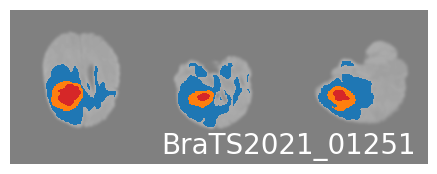

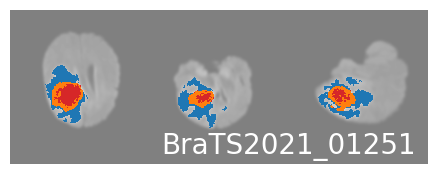

In [64]:
' Full segmentation '

i = 3

# Parameters
sigma = 2
dt_threshold = 2
H2_features_max = 20
alpha_boundary = .5 #value to consider inside/outside

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

# Segmentation
seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)
seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=False,plot=False)
seg_final   = Step3(seg_union,seg_contour,alpha_boundary=alpha_boundary,verbose=False)

# Plot
GetDICEs(seg_final,seg_medecin,verbose=True);
PlotSegmentation(pb,img_flair,seg_final,figsize=(6,2))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

# Batch full segmentations

In [65]:
' Full segmentation - batch '

i_list = range(100)
i_list = range(2)

# Parameters
sigma = 1
dt_threshold = 1
H2_features_max = 5
#alpha_boundary = .5 #value to consider inside/outside
ALPHAS = [0.5,0.85]

DICEs = {alpha_boundary:dict() for alpha_boundary in ALPHAS}

for alpha_boundary in ALPHAS:
    msg = 'Compute DICEs for alpha_boundary='+repr(alpha_boundary)+'... '
    start_time = ChronometerStart(msg)
    for i in i_list:
        # Open image
        pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
        img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

        # Segmentation
        seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)
        seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=False,plot=False)
        seg_final   = Step3(seg_union,seg_contour,alpha_boundary=alpha_boundary,verbose=False)

        # Result
        DICEs[alpha_boundary][i] = GetDICEs(seg_final,seg_medecin,verbose=False);
        ChronometerTick(start_time, i, len(i_list), msg)

Compute DICEs for alpha_boundary=0.5... It 2/2. Duration 0:01:21 Expected remaining time 0:00:00.
Compute DICEs for alpha_boundary=0.85... It 2/2. Duration 0:01:15 Expected remaining time 0:00:00.


alpha_boundary =  0.5
alpha_boundary =  0.85


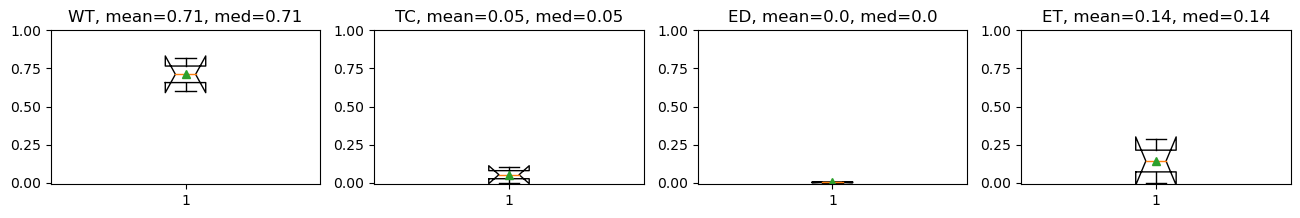

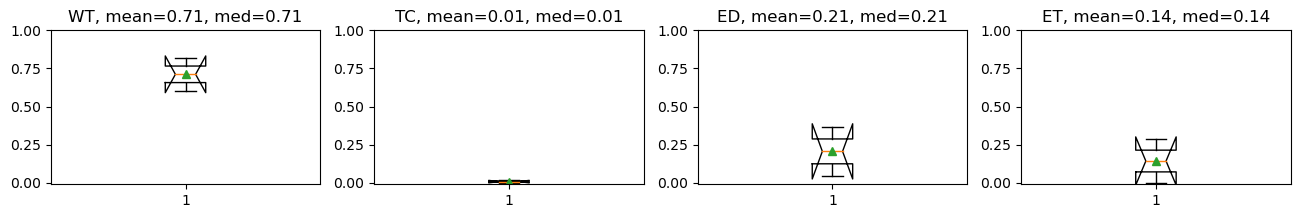

In [68]:
' Full segmentation - batch - boxplots '

for alpha_boundary in DICEs:
    print('alpha_boundary = ',alpha_boundary)
    dic = DICEs[alpha_boundary]
    BoxplotSegmentation(dic)

In [83]:
import itertools

' Full segmentation - batch - test parameters '

i_list = range(100)
i_list = range(1)

# Parameters
sigma = 1
SIGMAS = [0.5, 1]

dt_threshold = 1
DT_THRESHOLDS = [1,2]

H2_features_max = 5
H2_FEATURES = [5, 20]

#alpha_boundary = .5 #value to consider inside/outside
ALPHAS = [0.5,0.85]

PARAMETERS = list(itertools.product(SIGMAS,DT_THRESHOLDS,H2_FEATURES,ALPHAS))
print('There are', len(PARAMETERS), 'combinations of parameters to test')
DICEs = {parameters:dict() for parameters in PARAMETERS}

for parameters in PARAMETERS:
    sigma, dt_threshold, H2_features_max, alpha_boundary = parameters
    msg = 'Compute DICEs for parameters='+repr(parameters)+'... '
    start_time = ChronometerStart(msg)
    for i in i_list:
        # Open image
        pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
        img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

        # Segmentation
        seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)
        seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=False,plot=False)
        seg_final   = Step3(seg_union,seg_contour,alpha_boundary=alpha_boundary,verbose=False)

        # Result
        DICEs[parameters][i] = GetDICEs(seg_final,seg_medecin,verbose=False);
        ChronometerTick(start_time, i, len(i_list), msg)

There are 16 combinations of parameters to test
Compute DICEs for parameters=(0.5, 1, 5, 0.5)... 

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


Compute DICEs for parameters=(0.5, 1, 5, 0.5)... It 1/1. Duration 0:01:16 Expected remaining time 0:00:00.
Compute DICEs for parameters=(0.5, 1, 5, 0.85)... It 1/1. Duration 0:01:12 Expected remaining time 0:00:00.
Compute DICEs for parameters=(0.5, 1, 20, 0.5)... It 1/1. Duration 0:01:22 Expected remaining time 0:00:00.
Compute DICEs for parameters=(0.5, 1, 20, 0.85)... It 1/1. Duration 0:01:21 Expected remaining time 0:00:00.
Compute DICEs for parameters=(0.5, 2, 5, 0.5)... It 1/1. Duration 0:01:15 Expected remaining time 0:00:00.
Compute DICEs for parameters=(0.5, 2, 5, 0.85)... It 1/1. Duration 0:01:23 Expected remaining time 0:00:00.
Compute DICEs for parameters=(0.5, 2, 20, 0.5)... It 1/1. Duration 0:04:32 Expected remaining time 0:00:00.
Compute DICEs for parameters=(0.5, 2, 20, 0.85)... It 1/1. Duration 0:03:37 Expected remaining time 0:00:00.
Compute DICEs for parameters=(1, 1, 5, 0.5)... It 1/1. Duration 0:01:21 Expected remaining time 0:00:00.
Compute DICEs for parameters=(1

parameters =  (0.5, 1, 5, 0.5)
parameters =  (0.5, 1, 5, 0.85)
parameters =  (0.5, 1, 20, 0.5)
parameters =  (0.5, 1, 20, 0.85)
parameters =  (0.5, 2, 5, 0.5)
parameters =  (0.5, 2, 5, 0.85)
parameters =  (0.5, 2, 20, 0.5)
parameters =  (0.5, 2, 20, 0.85)
parameters =  (1, 1, 5, 0.5)
parameters =  (1, 1, 5, 0.85)
parameters =  (1, 1, 20, 0.5)
parameters =  (1, 1, 20, 0.85)
parameters =  (1, 2, 5, 0.5)
parameters =  (1, 2, 5, 0.85)
parameters =  (1, 2, 20, 0.5)
parameters =  (1, 2, 20, 0.85)


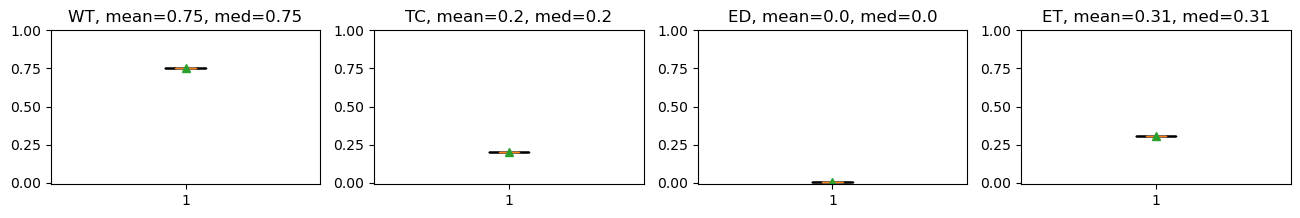

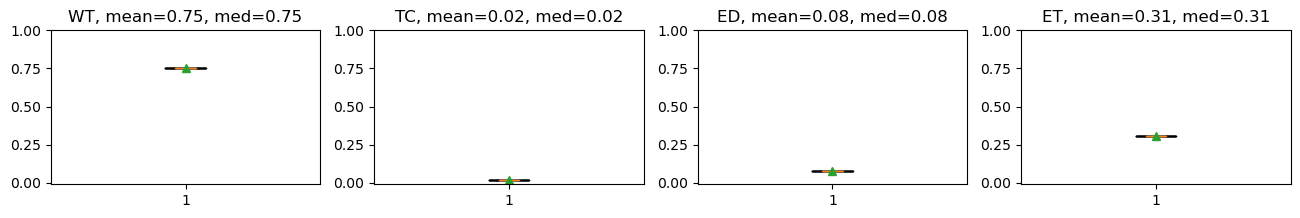

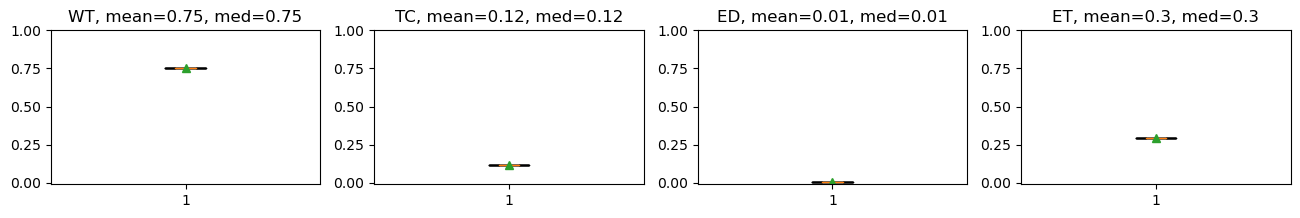

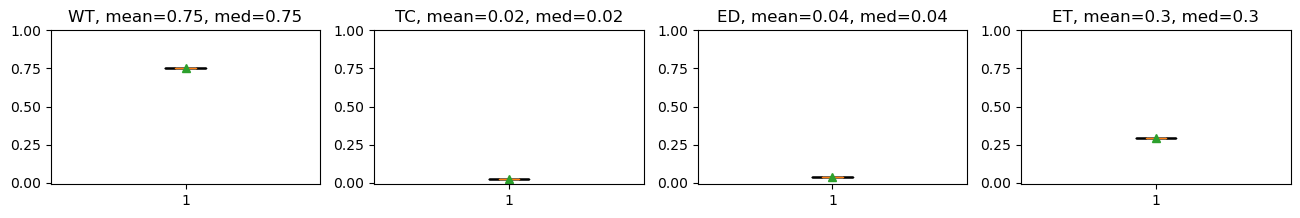

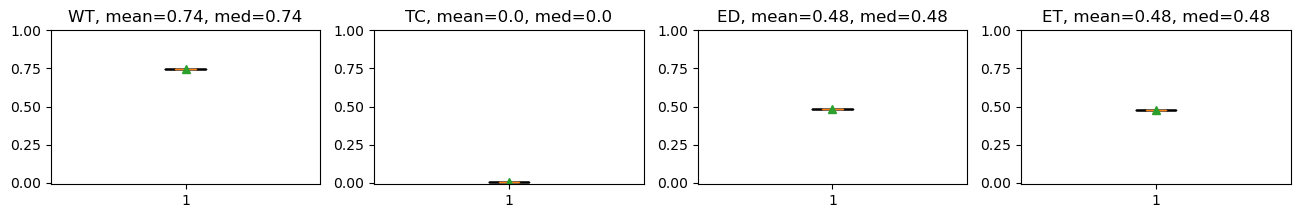

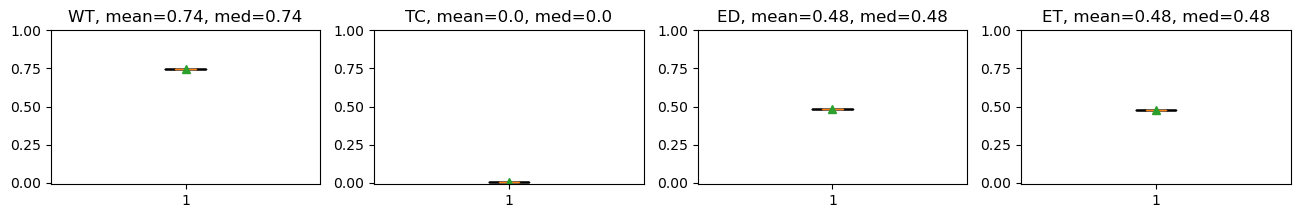

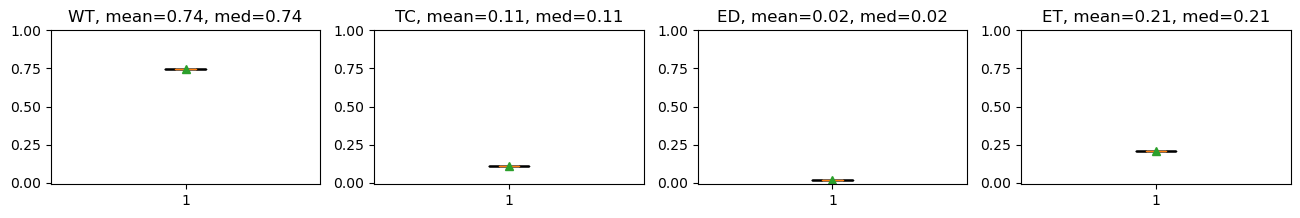

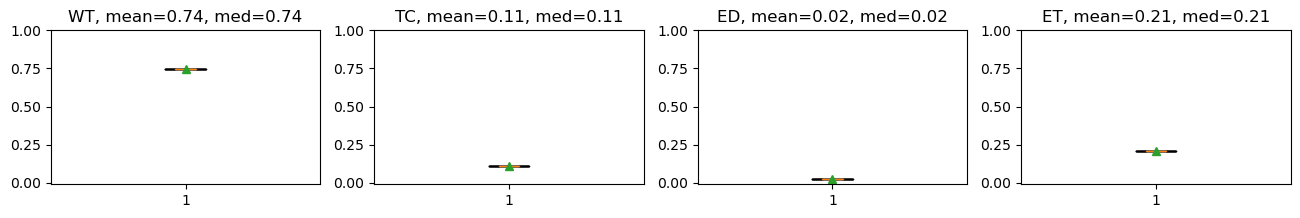

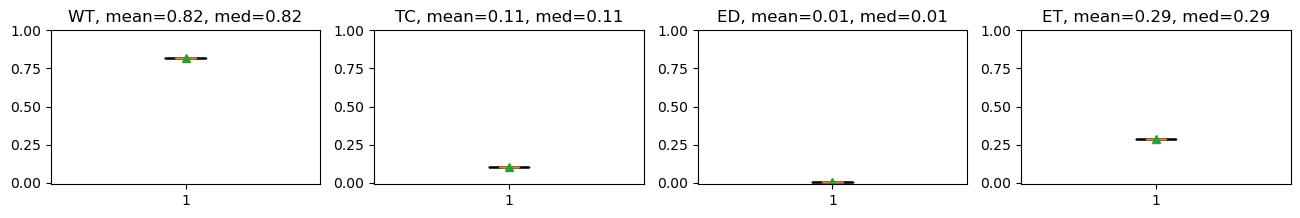

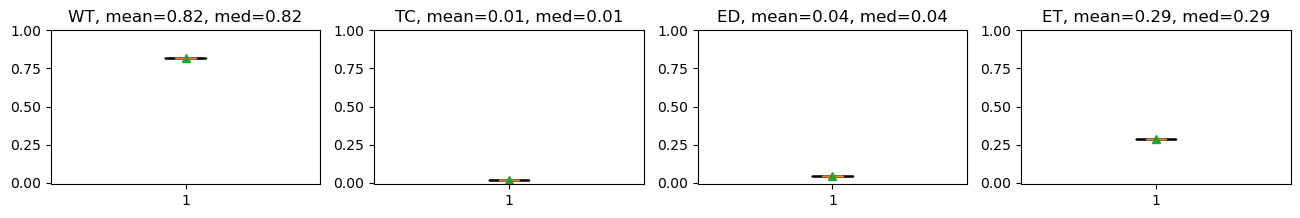

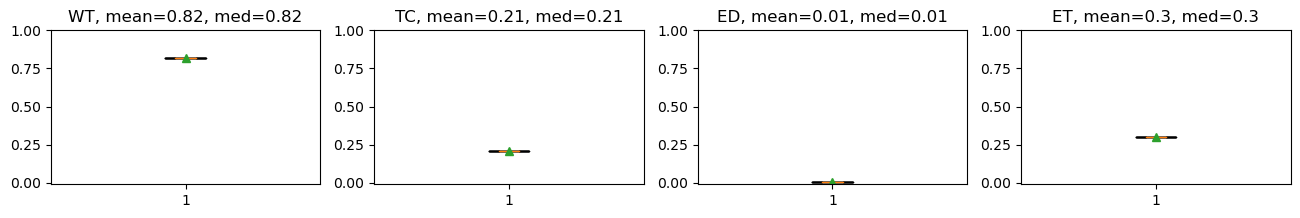

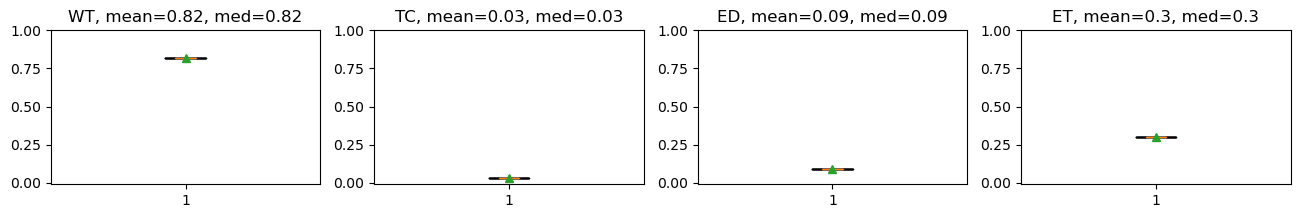

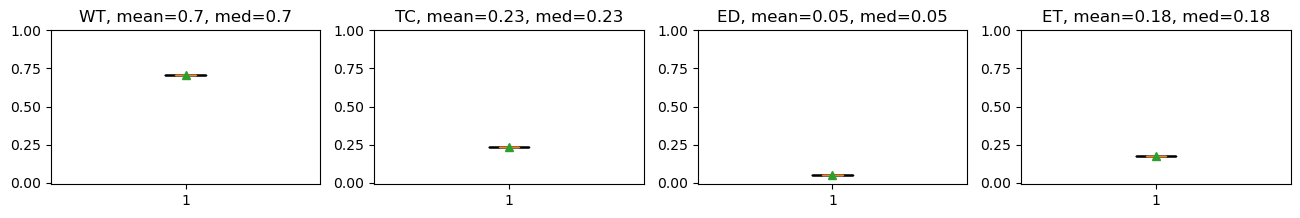

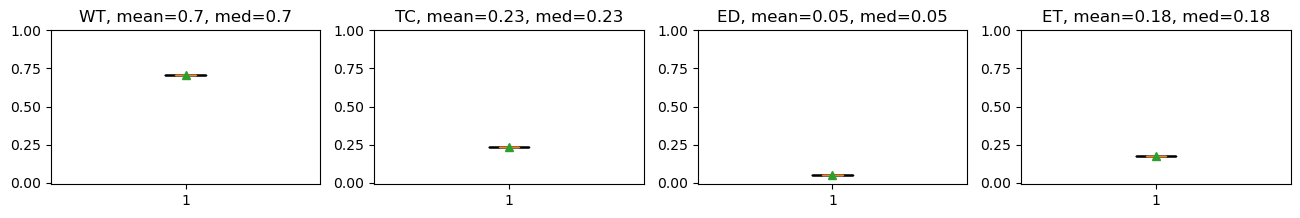

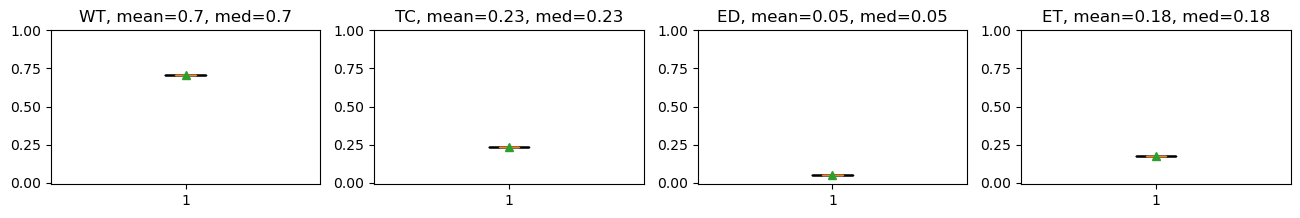

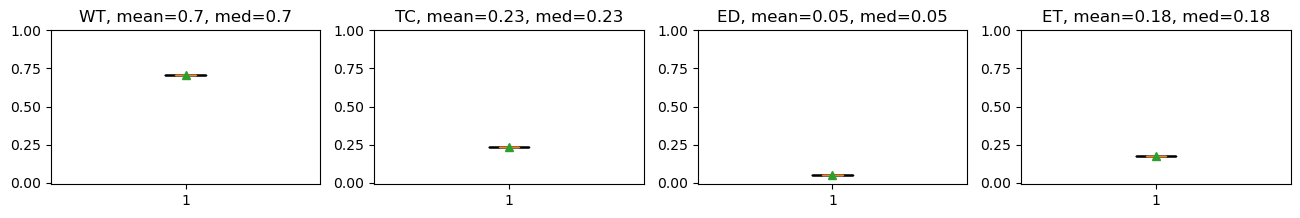

In [84]:
' Full segmentation - batch - test parameters - boxplots '

for parameters in PARAMETERS:
    print('parameters =',parameters)
    dic = DICEs[parameters]
    BoxplotSegmentation(dic)

# Compare with Unet

In [29]:
i = 2
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
filename = 'data/BenchmarkSegmentationsUnet/brats2021_seg/'+pb.brats_list[i]+'_seg__.nii.gz'
seg_unet  = nib.load(filename).get_fdata()
seg_unet[seg_unet==3]=4
assert set(seg_unet.flatten())=={0.0, 1.0, 2.0, 4.0}, 'Error'

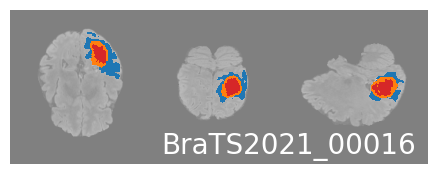

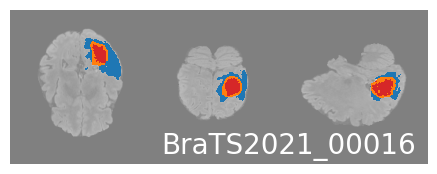

In [30]:
PlotSegmentation(pb,img_flair,seg_unet,figsize=(6,2))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

Compute scores for Unet... 

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


Compute scores for Unet... It 500/500. Duration 0:12:35 Expected remaining time 0:00:00.


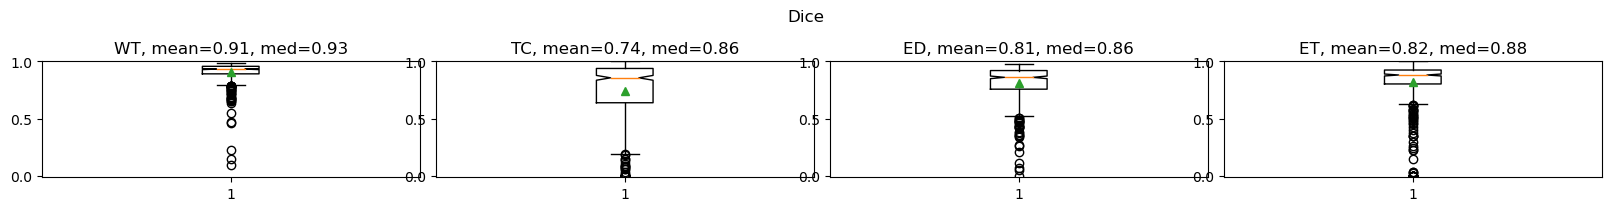

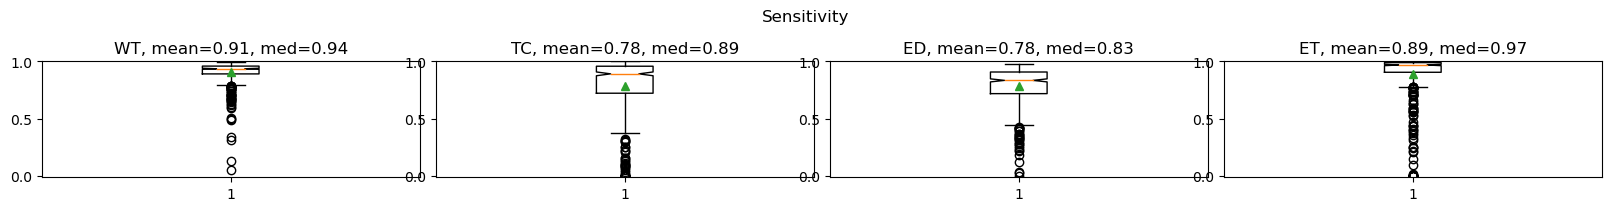

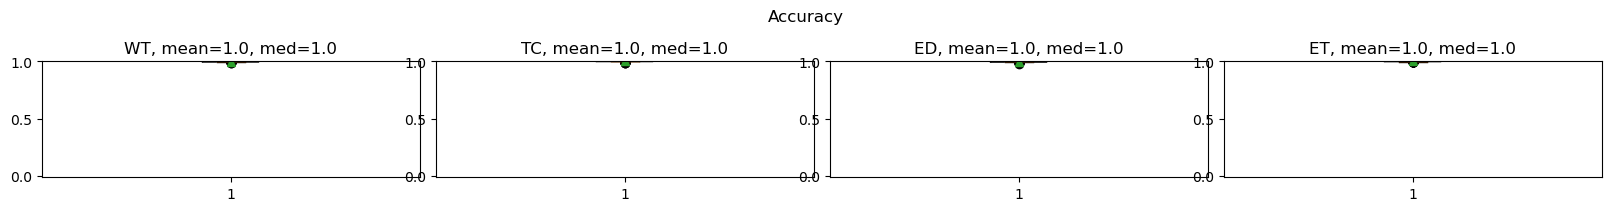

In [43]:
i_list = range(500)
DICEs, SENs, ACCs = dict(), dict(), dict()

msg = 'Compute scores for Unet... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    filename = 'data/BenchmarkSegmentationsUnet/brats2021_seg/'+pb.brats_list[i]+'_seg__.nii.gz'
    seg_unet  = nib.load(filename).get_fdata()
    seg_unet[seg_unet==3]=4
#    assert set(seg_unet.flatten())=={0.0, 1.0, 2.0, 4.0}, 'Error'

    # Result
    DICEs[i] = GetDICEs(seg_unet,seg_medecin,verbose=False);
    SENs[i]  = GetSensitivities(seg_unet,seg_medecin,verbose=False);
    ACCs[i]  = GetAccuracies(seg_unet,seg_medecin,verbose=False);
    
    ChronometerTick(start_time, i, len(i_list), msg)
       
' Unet segmentation - batch - test parameters - boxplots '

title = 'Dice'
dic = DICEs
BoxplotSegmentation(dic,title)
   
title = 'Sensitivity'
dic = SENs
BoxplotSegmentation(dic,title)
   
# title = 'Accuracy'
# dic = ACCs
# BoxplotSegmentation(dic,title)

' Unet segmentation - batch - test parameters - histograms '

title = 'Dice'
dic = DICEs
HistSegmentation(dic,title)
   
title = 'Sensitivity'
dic = SENs
HistSegmentation(dic,title)
   
# title = 'Accuracy'
# dic = ACCs
# HistSegmentation(dic,title)

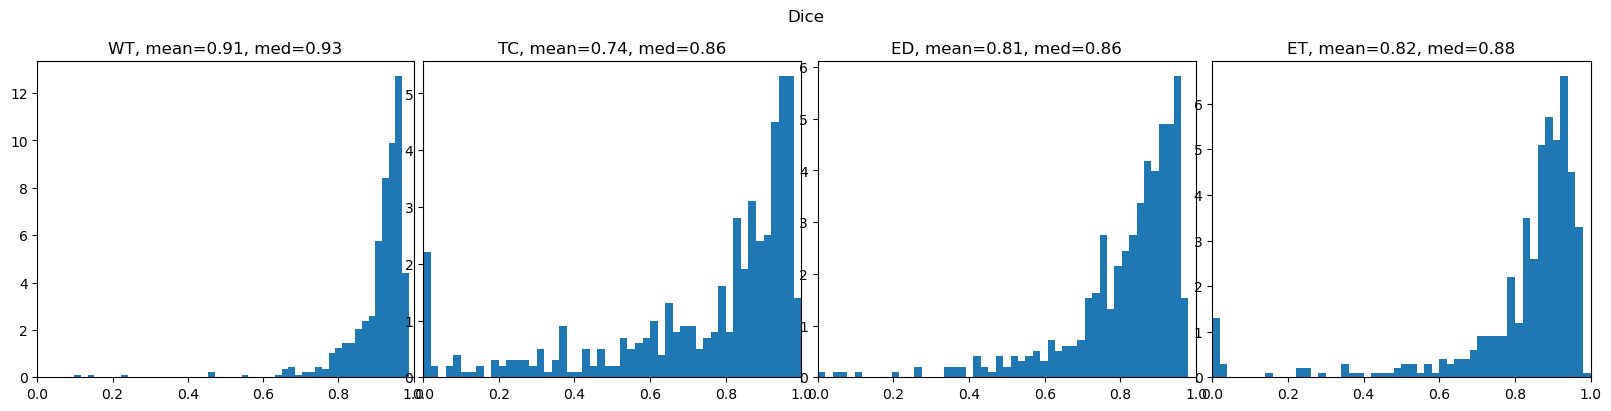

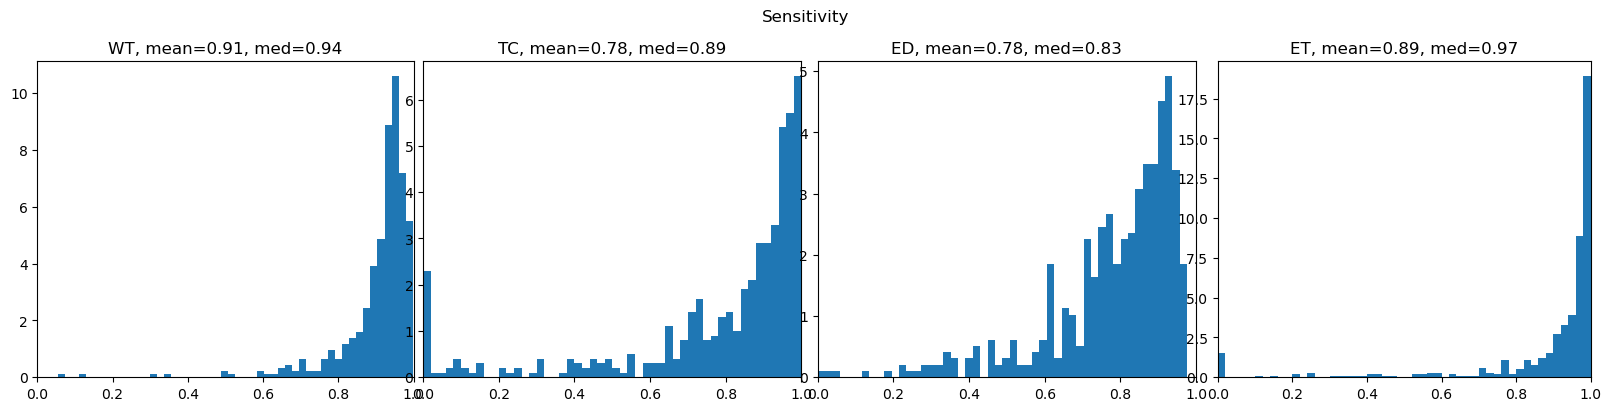

In [63]:
def HistSegmentation(dic, suptitle=None):
    Titles = ['WT', 'TC', 'ED', 'ET']
    Labels = [0,1,2,4]
    DICEs_list = list(dic.values())

    plt.figure(figsize =(4*4, 4),constrained_layout=True)
    for k in range(len(Labels)):
        label = Labels[k]
        scores = [dic[i][label] for i in dic]
        ax = plt.subplot(1,len(Labels),k+1)
        ax.hist(scores, density=True,bins=50)
        title = Titles[k]+', mean='+repr(round(np.mean(scores),2))+', med='+repr(round(np.median(scores),2))
        ax.title.set_text(title)
        ax.set_xlim(0,1)
    if suptitle is not None: plt.suptitle(suptitle)

In [36]:
def SEN(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    if seg_1.sum()==0: sen = 1
    else:              sen = prod_seg.sum() / seg_1.sum()
    return sen

def GetSensitivities(seg_1,seg_2, verbose=False):
    sens = {l:SEN((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    sens[0] = SEN((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    return sens

def ACC(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    prod_seg_complement = (1-seg_1) * (1-seg_2)
    acc = (prod_seg.sum()+prod_seg_complement.sum())/np.prod(np.shape(seg_1))
    return acc

def GetAccuracies(seg_1,seg_2, verbose=False):
    accs = {l:ACC((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    accs[0] = ACC((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    return accs

def DICE(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    sum_seg = seg_1 + seg_2
    if sum_seg.sum()==0: dice = 1
    else: dice = 2 * prod_seg.sum() / sum_seg.sum()
    if verbose:
        # Non-symmetric scores
        diceleft  = prod_seg.sum() / seg_1.sum()
        diceright = prod_seg.sum() / seg_2.sum()
        print('Sørensen–Dice coefficient: ',round(dice,3), round(diceleft,3), round(diceright,3))
    return dice

def GetDICEs(seg_1,seg_2, verbose=False):
    dices = {l:DICE((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    dices[0] = DICE((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    if verbose: print('Sørensen–Dice coefficients:', {l:round(dices[l],3) for l in [1,2,4]})
    return dices 